# NYC Demographic Analysis: Race, Ethnicity, Location Quotients & Investor Housing

Luis Edgar Vargas Ramirez  

**Data sources:**
- [U.S. Census Bureau American Community Survey (ACS) 2022, NYC](https://www.census.gov/programs-surveys/acs)
- [Redfin 2023 NYC Investor Market & Purchase Estimates](https://www.redfin.com/news/data-center/)

---

## Introduction

R has become a very important tool in the GIS world, and knowing how to manage data is an essential skill for anyone who is interested in creating maps. This notebook walks the reader through the process of writing code to prepare data in R for a future use in a GIS program.

This notebook is organized into three parts:

**Part 1 — Data Cleaning & Feature Engineering:** Loading the NYC census tract GeoPackage, handling missing values, and computing derived demographic variables (percentages, ratios, densities) for race and Hispanic ethnicity groups.

**Part 2 — Location Quotients:** Computing the Location Quotient (LQ) for the four main race groups to identify areas of over and under representation relative to the citywide average.

**Part 3 — Redfin Investor Data:** Loading, cleaning, and joining Redfin 2023 investor purchase estimates to the census tract geography to prepare data for spatial analysis of housing market patterns.

---
# Part 1.  Data Cleaning & Feature Engineering
---

## 1.1 Set Up

Let's start by loading the needed libraries. Libraries are packages that contain functions specific to different tasks. Base R comes with a few default libraries that are not necessarily useful for this work, which is why specific libraries are needed.

The libraries needed are:
- `sf` — stands for Simple Feature; allows R to apply functions needed to handle geographic data
- `sp` — used for geo-spatial analysis
- `dplyr` — a data manipulations library that simplifies tasks by improving syntax
- `rmarkdown` — allows user to have an interface for notebook creation
- `knitr` — helps rmarkdown render the notebooks created

In [3]:
# Install packages if needed (uncomment to run)
install.packages("sf")
install.packages("sp")
install.packages("dplyr")
install.packages("rmarkdown")
install.packages("knitr")
install.packages("rlang", repos = "https://cran.r-project.org")

Warning message:
"package 'sf' is in use and will not be installed"
Warning message:
"package 'sp' is in use and will not be installed"
Installing package into 'C:/Users/REDGA/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)

also installing the dependencies 'rlang', 'vctrs'




package 'rlang' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'rlang'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\REDGA\AppData\Local\R\win-library\4.5\00LOCK\rlang\libs\x64\rlang.dll to C:\Users\REDGA\AppData\Local\R\win-library\4.5\rlang\libs\x64\rlang.dll: Permission denied"
Warning message:
"restored 'rlang'"


package 'vctrs' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'vctrs'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\REDGA\AppData\Local\R\win-library\4.5\00LOCK\vctrs\libs\x64\vctrs.dll to C:\Users\REDGA\AppData\Local\R\win-library\4.5\vctrs\libs\x64\vctrs.dll: Permission denied"
Warning message:
"restored 'vctrs'"


...

package 'knitr' successfully unpacked and MD5 sums checked

The downloaded binary packages are in
	C:\Users\REDGA\AppData\Local\Temp\RtmpEBRQ4h\downloaded_packages


Installing package into 'C:/Users/REDGA/AppData/Local/R/win-library/4.5'
(as 'lib' is unspecified)



package 'rlang' successfully unpacked and MD5 sums checked


Warning message:
"cannot remove prior installation of package 'rlang'"
Warning message in file.copy(savedcopy, lib, recursive = TRUE):
"problem copying C:\Users\REDGA\AppData\Local\R\win-library\4.5\00LOCK\rlang\libs\x64\rlang.dll to C:\Users\REDGA\AppData\Local\R\win-library\4.5\rlang\libs\x64\rlang.dll: Permission denied"
Warning message:
"restored 'rlang'"



The downloaded binary packages are in
	C:\Users\REDGA\AppData\Local\Temp\RtmpEBRQ4h\downloaded_packages


In [1]:
library(sf)        # Simple Features for R - Handling Geographic Data
library(sp)        # Classes and Methods for Spatial Data
library(dplyr)     # A Grammar for Data Manipulation
library(rmarkdown) # Notebook Interface to Produce Elegantly Formatted Output
library(knitr)     # Elegant, Flexible, and Fast Dynamic Report Generation

Warning message:
"package 'sf' was built under R version 4.5.3"
Linking to GEOS 3.14.1, GDAL 3.12.1, PROJ 9.7.1; sf_use_s2() is TRUE

Warning message:
"package 'sp' was built under R version 4.5.3"
Warning message:
"package 'dplyr' was built under R version 4.5.3"

Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union


Warning message:
"package 'rmarkdown' was built under R version 4.5.3"
Warning message:
"package 'knitr' was built under R version 4.5.3"


Now that the libraries are loaded, the next step is to set a path to the folder where the needed geo-files are located.
Update the path below to point to your local `data/` folder.

In [2]:
# Set working directory to the data folder
# Update this path to match your local setup
setwd("C:/Users/REDGA/Downloads")

# Verify the directory and files are accessible
list.dirs()
list.files()

[1] "."                                                                       
[2] "./.ipynb_checkpoints"                                                    
[3] "./2 reports"                                                             
[4] "./Armoury_Crate_Uninstall_Tool"                                          
[5] "./Armoury_Crate_Uninstall_Tool/Armoury Crate Uninstall Tool V2.3.1.0"    
[6] "./Armoury_Crate_Uninstall_Tool/Armoury Crate Uninstall Tool V2.3.1.0/dll"
[7] "./GHelper"                                                               
[8] "./phase2_outputs"

[1] "2 reports"                                                    
  [2] "2 reports(1).zip"                                             
  [3] "2 reports(2).zip"                                             
  [4] "2 reports.zip"                                                
  [5] "24x24_matrix_of_d_i_d_j__zeros_where_no_join_.csv"            
  [6] "4databases.pptx"                                              
  [7] "Administration_and_Management.xlsx"                           
  [8] "AdventureWorks Calendar Lookup.csv"                           
  [9] "AdventureWorks Customer Lookup.csv"                           
 [10] "AdventureWorks Product Categories Lookup.csv"                 
 [11] "AdventureWorks Product Lookup.csv"                            
 [12] "AdventureWorks Product Subcategories Lookup.csv"              
 [13] "AdventureWorks Report_sesion_11.pbix"                         
 [14] "AdventureWorks Report_sesion_12.pbix"                         
 [15] "AdventureWorks Returns Data.csv"                              
 [16] "AdventureWorks Sales Data 2020.csv"                           
 [17] "AdventureWorks Sales Data 2021.csv"                           
 [18] "AdventureWorks Sales Data 2022.csv"                           
 [19] "AdventureWorks Territory Lookup.csv"                          
 [20] "Allinone_PDF_report.pdf"                                      
 [21] "Allinone_PDF_report_2-1.pdf"                                  
 [22] "Allinone_PDF_report_2.pdf"                                    
 [23] "Anaconda3-2025.06-0-Windows-x86_64.exe"                       
 [24] "annotated-HW_1.pptx.pdf"                                      
 [25] "annotated_1_5_vertices5.png"                                  
 [26] "annotated_1_5_vertices5_corrected.png"                        
 [27] "ArcGISPro_35_195271.exe"                                      
 [28] "Armoury_Crate_Uninstall_Tool"                                 
 [29] "Armoury_Crate_Uninstall_Tool.zip"                             
 [30] "Audio_DriverOnly_Dolby_ROG_Realtek_B_V6.0.9823.1_43546_1.exe" 
 [31] "Business Summary, Springfield_IL.pdf"                         
 [32] "Business Summary, Springfield_VA.pdf"                         
 [33] "Business_Summary_My_Springfield.pdf"                          
 [34] "Business_Summary_My_Springfield_2.pdf"                        
 [35] "Business_Summary_Springfield_IL_2.pdf"                        
 [36] "cb_2022_us_tract510_500k_nyc.gpkg"                            
 [37] "check_vcredist.exe"                                           
 [38] "ChromeSetup.exe"                                              
 [39] "Cover_Letter_Mathematica.docx"                                
 [40] "curp.pdf"                                                     
 [41] "CV_2025.docx"                                                 
 [42] "Demographic_and_Income_Comparison_Profile_Springfield_VA.pdf" 
 [43] "departamentos.csv"                                            
 [44] "desktop.ini"                                                  
 [45] "DS606_TeamC_Mussa_Ramirez_Duvall_Hospital_Readmission_P1.pptx"
 [46] "EAappInstaller.exe"                                           
 [47] "Final project guideline.docx"                                 
 [48] "final_verified_nodes_1_5.png"                                 
 [49] "Firefox Installer.exe"                                        
 [50] "GeoDa-Windows7+-x64-installer.zip"                            
 [51] "GEOG653_Lecture_8_Surface Analysis - Part I.pdf"              
 [52] "GEOG655HW3 Mac.pdf"                                           
 [53] "GEOG655HW3SQL.pdf"                                            
 [54] "GHelper"                                                      
 [55] "GHelper.zip"                                                  
 [56] "GIS_Database_ER_Diagram.pptx"                                 
 [57] "GIS_Database_ER_Diagram_Conceptual_Logical_v2.pptx"           
 [58] "hotsp

## 1.2 Exploratory Data Analysis

Before processing the data, it is good coding practice to assign the geo-package file to a variable `nyc_gpkg`.
This is mostly for practicality when using the geo-package file in the future, as it will save time.

In [3]:
nyc_gpkg <- "cb_2022_us_tract510_500k_nyc.gpkg"

In order to understand the geo-package file, the layers inside it need to be read. The function `st_layers` helps to read the different layers in a spatial data file.

In [4]:
layer <- st_layers(nyc_gpkg)
print(layer)

Driver: GPKG 
Available layers:
                        layer_name geometry_type features fields
1    cb_2022_us_county510_500k_nyc       Polygon        7     10
2 cb_2022_us_tract510_500k_nyc_v2b Multi Polygon     2164     47
                               crs_name
1 North_America_Albers_Equal_Area_Conic
2 North_America_Albers_Equal_Area_Conic


There are two layers in the package, but there is only need for one: **cb_2022_us_tract510_500k_nyc_v2b**. In order to get to this layer, `st_read` is used. Then the variable `trct` is assign to it.

In [5]:
trct <- st_read(nyc_gpkg, layer = "cb_2022_us_tract510_500k_nyc_v2b")

Reading layer `cb_2022_us_tract510_500k_nyc_v2b' from data source 
  `C:\Users\REDGA\Downloads\cb_2022_us_tract510_500k_nyc.gpkg' 
  using driver `GPKG'
Simple feature collection with 2164 features and 47 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 1718547 ymin: 256723.3 xmax: 1756681 ymax: 311508
Projected CRS: North_America_Albers_Equal_Area_Conic


Now, the data inspection starts, using the functions `head()` and `tail()`.

In [6]:
print(head(trct)) # examine a sample of the top of data for visual affirmation.
print(tail(trct)) # examine a sample of the tail of data for visual affirmation.

Simple feature collection with 6 features and 47 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 1735824 ymin: 284988.8 xmax: 1746260 ymax: 294037.6
Projected CRS: North_America_Albers_Equal_Area_Conic
  OBJECTID STATEFP COUNTYFP TRACTCE       GEOID  NAME           NAMELSAD MTFCC
1        1      36      081  003400 36081003400    34    Census Tract 34 G5020
2        2      36      081  003900 36081003900    39    Census Tract 39 G5020
3        3      36      081  003600 36081003600    36    Census Tract 36 G5020
4        4      36      081  003700 36081003700    37    Census Tract 37 G5020
5        5      36      081  003800 36081003800    38    Census Tract 38 G5020
6        6      36      081  004001 36081004001 40.01 Census Tract 40.01 G5020
  FUNCSTAT  ALAND AWATER    INTPTLAT     INTPTLON GEOID_TRACT CNT_BLK_GRP
1        S 213987      0 +40.6847731 -073.8581871 36081003400           2
2        S 146970      0 +40.7627994 -073.9409316 36081003900          

The next code lines will help us know what the name of each attribute is, the number of attributes, and the data type for each.
These functions are helpful for data exploration and preparation for future data processing because they provide useful information.

In [7]:
names(trct)  # list the attributes.
ncol(trct)   # number of columns/attributes
str(trct)    # list the attribute data types.

[1] "OBJECTID"    "STATEFP"     "COUNTYFP"    "TRACTCE"     "GEOID"      
 [6] "NAME"        "NAMELSAD"    "MTFCC"       "FUNCSTAT"    "ALAND"      
[11] "AWATER"      "INTPTLAT"    "INTPTLON"    "GEOID_TRACT" "CNT_BLK_GRP"
[16] "GEO_ID"      "LABLE"       "STATE_FIPS"  "COUNTY_FIPS" "TRACT_FIPS" 
[21] "DP05_0033E"  "DP05_0037E"  "DP05_0038E"  "DP05_0039E"  "DP05_0044E" 
[26] "DP05_0052E"  "DP05_0057E"  "DP05_0058E"  "DP05_0072E"  "DP05_0073E" 
[31] "DP05_0074E"  "DP05_0075E"  "DP05_0076E"  "DP05_0077E"  "DP05_0078E" 
[36] "DP05_0079E"  "DP05_0080E"  "DP05_0081E"  "DP05_0082E"  "DP05_0083E" 
[41] "DP05_0084E"  "DP05_0085E"  "DP05_5758E"  "DP05_0037P"  "DP05_0038P" 
[46] "DP05_0044P"  "DP05_3958P"  "geom"

[1] 48

Classes 'sf' and 'data.frame':	2164 obs. of  48 variables:
 $ OBJECTID   : num  1 2 3 4 5 6 7 8 9 10 ...
 $ STATEFP    : chr  "36" "36" "36" "36" ...
 $ COUNTYFP   : chr  "081" "081" "081" "081" ...
 $ TRACTCE    : chr  "003400" "003900" "003600" "003700" ...
 $ GEOID      : chr  "36081003400" "36081003900" "36081003600" "36081003700" ...
 $ NAME       : chr  "34" "39" "36" "37" ...
 $ NAMELSAD   : chr  "Census Tract 34" "Census Tract 39" "Census Tract 36" "Census Tract 37" ...
 $ MTFCC      : chr  "G5020" "G5020" "G5020" "G5020" ...
 $ FUNCSTAT   : chr  "S" "S" "S" "S" ...
 $ ALAND      : num  213987 146970 180006 386629 176214 ...
 $ AWATER     : num  0 0 0 14591 0 ...
 $ INTPTLAT   : chr  "+40.6847731" "+40.7627994" "+40.6837714" "+40.7624148" ...
 $ INTPTLON   : chr  "-073.8581871" "-073.9409316" "-073.8568176" "-073.9434494" ...
 $ GEOID_TRACT: chr  "36081003400" "36081003900" "36081003600" "36081003700" ...
 $ CNT_BLK_GRP: int  2 2 1 3 1 2 1 2 1 2 ...
 $ GEO_ID     : chr  "140000

## 1.3 Data Cleaning

In order to start cleaning the data, it is important to know if there are any missing values, duplicates, or any other problems with the data entry. For this particular example, **NaN** is a problem that needs to be fixed.

The next functions help identify the number of **NaN** values in the data set. They both perform exactly the same task. I personally prefer the second one because it keeps the code shorter and more organized, but the choice is up to the personal preference of the coder.

In [8]:
mvals <- is.na(trct)
sum(mvals)

# or — shorter version
sum(is.na(trct))

[1] 4379

[1] 4379

Identifying the columns that have missing values will help us prepare a solution to each specific target, without compromising the rest of the data set. It is important to understand what is happening with missing values. There could be more information about why those values are missing, giving important context to the analysis.

In [9]:
cmiss <- colSums(is.na(trct)) > 0
names(trct)[cmiss]

[1] "CNT_BLK_GRP" "GEO_ID"      "LABLE"       "STATE_FIPS"  "COUNTY_FIPS"
 [6] "TRACT_FIPS"  "DP05_0033E"  "DP05_0037E"  "DP05_0038E"  "DP05_0039E" 
[11] "DP05_0044E"  "DP05_0052E"  "DP05_0057E"  "DP05_0058E"  "DP05_0072E" 
[16] "DP05_0073E"  "DP05_0074E"  "DP05_0075E"  "DP05_0076E"  "DP05_0077E" 
[21] "DP05_0078E"  "DP05_0079E"  "DP05_0080E"  "DP05_0081E"  "DP05_0082E" 
[26] "DP05_0083E"  "DP05_0084E"  "DP05_0085E"  "DP05_5758E"  "DP05_0037P" 
[31] "DP05_0038P"  "DP05_0044P"  "DP05_3958P"

The next code line will help set up a more organized and clean environment by removing `mvals` and `cmiss` from memory. This is another example of good coding practice.

In [10]:
remove(mvals, cmiss)

In order to replace the **NaN** values in the numeric columns to **0**, first a list that contains all the numeric columns with **NaN** values is created. After this those values are replaced to **0** using the `lapply()` function.

The `lapply()` function applies the function `is.na()` to each element of the columns selected. If the value is **NaN**, the function replaces it to **0**, and if it is not, the value is kept. This replacement is possible thanks to the function `ifelse()`.

> **Note:** The following columns are not numeric or where substituting **NaN** for **0** would not be useful:  
> `CNT_BLK_GRP` (int), `GEO_ID` (chr), `LABLE` (chr), `STATE_FIPS` (int), `COUNTY_FIPS` (int), `TRACT_FIPS` (int)

In [11]:
numeric_columns_with_na <- c(
  "DP05_0033E", "DP05_0037E", "DP05_0038E", "DP05_0039E",
  "DP05_0044E", "DP05_0052E", "DP05_0057E", "DP05_0058E", "DP05_0072E",
  "DP05_0073E", "DP05_0074E", "DP05_0075E", "DP05_0076E", "DP05_0077E",
  "DP05_0078E", "DP05_0079E", "DP05_0080E", "DP05_0081E", "DP05_0082E",
  "DP05_0083E", "DP05_0084E", "DP05_0085E", "DP05_5758E", "DP05_0037P",
  "DP05_0038P", "DP05_0044P", "DP05_3958P"
)

# Replace NA values with 0 in the specified columns
trct[numeric_columns_with_na] <- lapply(
  trct[numeric_columns_with_na],
  function(x) ifelse(is.na(x), 0, x)
)

Warning message in `[<-.data.frame`(`*tmp*`, numeric_columns_with_na, value = list(:
"provided 28 variables to replace 27 variables"


In order to ensure that the replacement process functioned as planned, is important check which columns still have the value **NaN**. These columns shouldn't be added to the `numeric_columns_with_na` list.

In [12]:
sum(is.na(trct)) # NaN values should have dropped from 4379 to 662
cmiss <- colSums(is.na(trct)) > 0
names(trct)[cmiss] # These are the columns that contain the remaining NaN values

[1] 662

[1] "CNT_BLK_GRP" "GEO_ID"      "LABLE"       "STATE_FIPS"  "COUNTY_FIPS"
[6] "TRACT_FIPS"

## 1.4 Data Dictionary; 2022 American Community Survey (Race & Ethnicity)

In order to better understand this next part of the project, it is important to know what each race group code is according to the 2022 race and ethnicity dictionary.

| Field Name | Short Description |
|---|---|
| GEO_ID | Geographic Identifier |
| NAME | Geographic Area Name |
| DP05_0033E | Total Population Estimate |
| DP05_0037E | Estimate — White Alone |
| DP05_0038E | Estimate — Black or African American Alone |
| DP05_0039E | Estimate — American Indian and Alaska Native Alone |
| DP05_0044E | Estimate — Asian Alone |
| DP05_0052E | Estimate — Native Hawaiian and Other Pacific Islander Alone |
| DP05_0057E | Estimate — Some Other Race Alone |
| DP05_0058E | Estimate — Two or More Races |
| DP05_0072E | Total Population — Hispanic or Latino and Race |
| DP05_0073E | Estimate — Hispanic or Latino (of Any Race) |
| DP05_0074E | Estimate — Mexican |
| DP05_0075E | Estimate — Puerto Rican |
| DP05_0076E | Estimate — Cuban |
| DP05_0077E | Estimate — Other Hispanic or Latino |
| DP05_0078E | Estimate — Not Hispanic or Latino |
| DP05_0079E | Estimate — White Alone (Not Hispanic or Latino) |
| DP05_0080E | Estimate — Black or African American Alone (Not Hispanic or Latino) |
| DP05_0081E | Estimate — American Indian and Alaska Native Alone (Not Hispanic or Latino) |
| DP05_0082E | Estimate — Asian Alone (Not Hispanic or Latino) |
| DP05_0083E | Estimate — Native Hawaiian and Other Pacific Islander Alone (Not Hispanic or Latino) |
| DP05_0084E | Estimate — Some Other Race Alone (Not Hispanic or Latino) |
| DP05_0085E | Estimate — Two or More Races (Not Hispanic or Latino) |

## 1.5 Data Visualization

Data visualization is a great way to gain new insights about the data. In this a geographic visualization will help represent the data. Representing the data as a geometry also helps ensure there is not missing data from any locations. This is specially important with geolocation data because it is hard to analyze in a relational data set.

Warning message:
"plotting the first 9 out of 47 attributes; use max.plot = 47 to plot all"


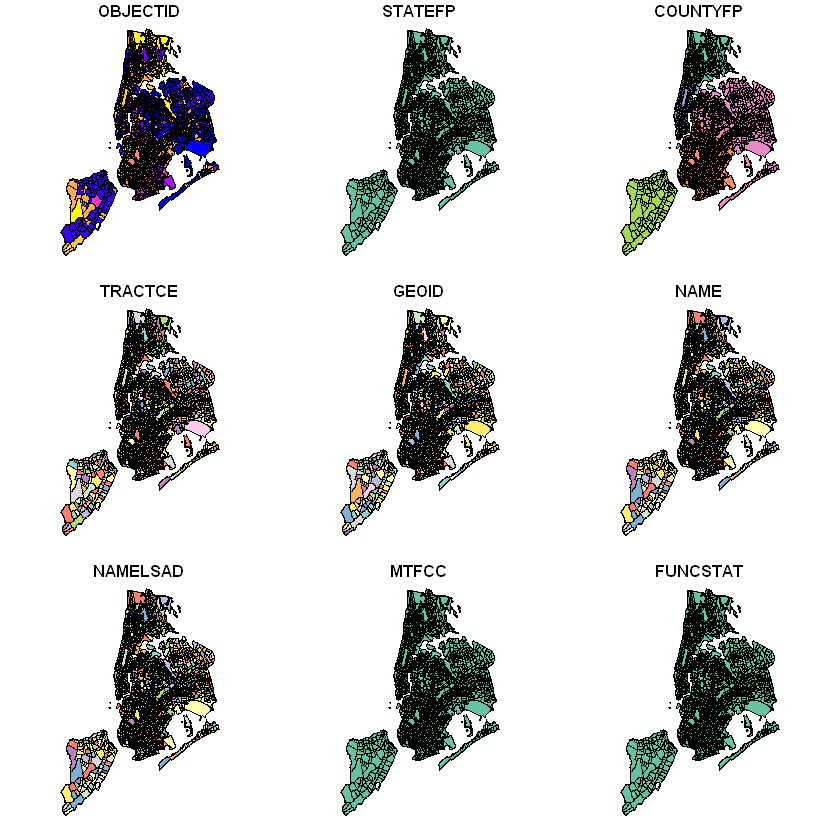

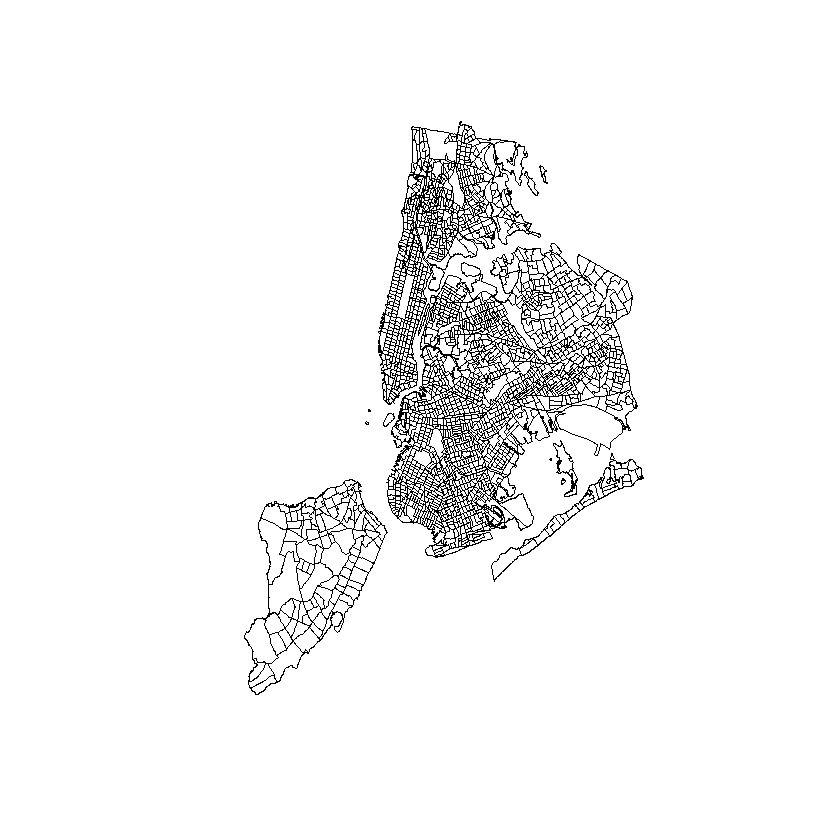

In [13]:
# Plotting based on "OBJECTID" or "NAME" is an example of how this is not a desired result.
plot(trct) # plots a map for each variable — generates many plots

# This code will help check the geometry and make sure nothing is missing in it.
plot(st_geometry(trct)) # plot only a map of the geography — the preferred check

## 1.6 Group Examination

Examining the race groups helps to understand the distribution better, and knowing the size of each group gives us an idea of the effects a specific race group might have on others.

The `as.data.frame()` is used to ensure the object is a data frame. In data analysis, working with data frames is not only easier but also more versatile, as they allow for efficient data manipulation.

In [14]:
colSums(as.data.frame(trct)[, c("DP05_0037E", "DP05_0038E", "DP05_0039E", "DP05_0044E", "DP05_0052E")], na.rm = TRUE)
colSums(as.data.frame(trct)[, c("DP05_0057E", "DP05_0058E")], na.rm = TRUE)

DP05_0037E DP05_0038E DP05_0039E DP05_0044E DP05_0052E 
   2905117    1798120      48241    1105218       4762

DP05_0057E DP05_0058E 
   1212193     705372

**White**, **black**, and **asian** have significantly larger populations compared to **native Hawaiian and other Pacific Islanders**, **American Indian and Alaska Natives**, **some other race alone** and **two or more races**. The smaller groups have low representation, making it challenging to analyze trends or draw meaningful conclusions.

In order to alleviate this issue, a new group named **OTHER_RACES** is created, which sums all the smallest groups. Now there is only 4 different race groups: **white**, **black**, **asian** and **OTHER_RACES**. This new group will allow us to more effectively analyze the representation the other race groups have.

> **Note on `mutate()`:**`dplyr::mutate()` is used here to add new columns to the data frame. This is the modern preferred approach over `attach()`/`detach()` because it is explicit about which data frame is being modified, avoids polluting the global namespace, and is safer when working with multiple data frames simultaneously.

In [15]:
# Create OTHER_RACES: sum of the four smaller race subgroups
# American Indian & Alaska Native + Native Hawaiian & Pacific Islander +
# Some Other Race Alone + Two or More Races
trct <- mutate(trct, OTHER_RACES = DP05_0057E + DP05_0058E + DP05_0039E + DP05_0052E)

sum(trct$OTHER_RACES) # verify the column was created

[1] 1970568

## 1.7 Basic Percentage

Percentage is a great way to understand the relative size of a group related to the total group population. It helps us analyze group trends, group sizes, and how population is distributed within these groups.

To have a deeper understanding of the percentage and the specific group, a `summary()` and `hist()` analysis are made. These two functions provide a comprehensive and complementary view of the data. The `summary()` function gives us general knowledge of the data, providing values like mean, median, max, min, etc. The `hist()` function provides a visual representation of the distribution, which helps identify if the data is skewed, has outliers or major data distribution problems.

### Race groups

For the race groups, each group will be divided by the Total Population Estimate and multiplied by 100.

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0   265.8   930.5  1342.5  1906.5 12272.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   0.00   12.28   32.29   37.09   60.89  100.00     176 

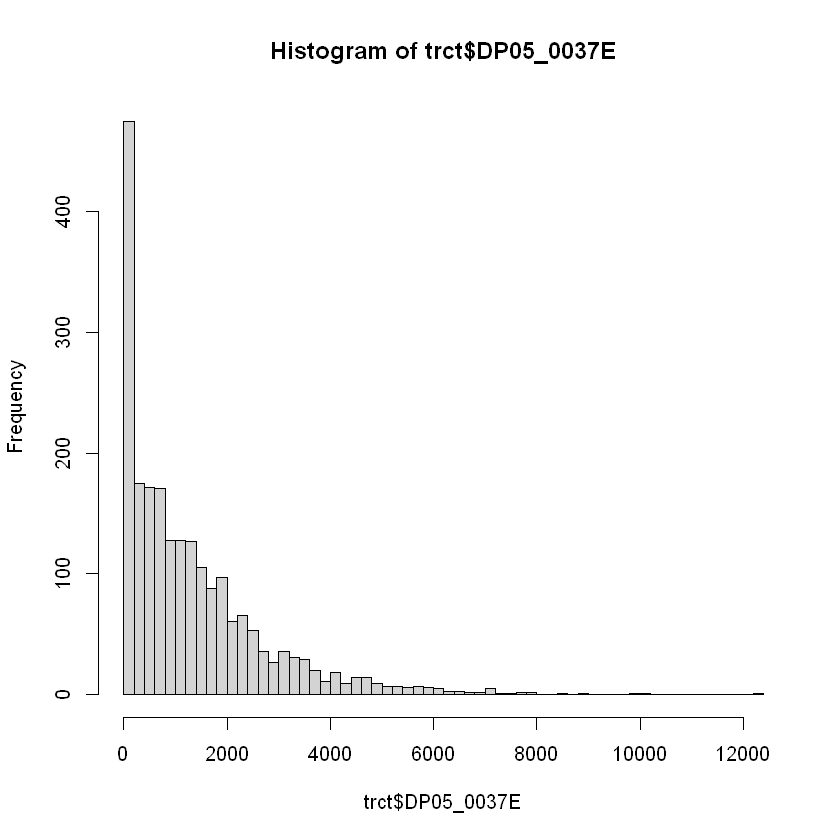

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0    42.0   282.0   830.9  1358.8  7338.0 

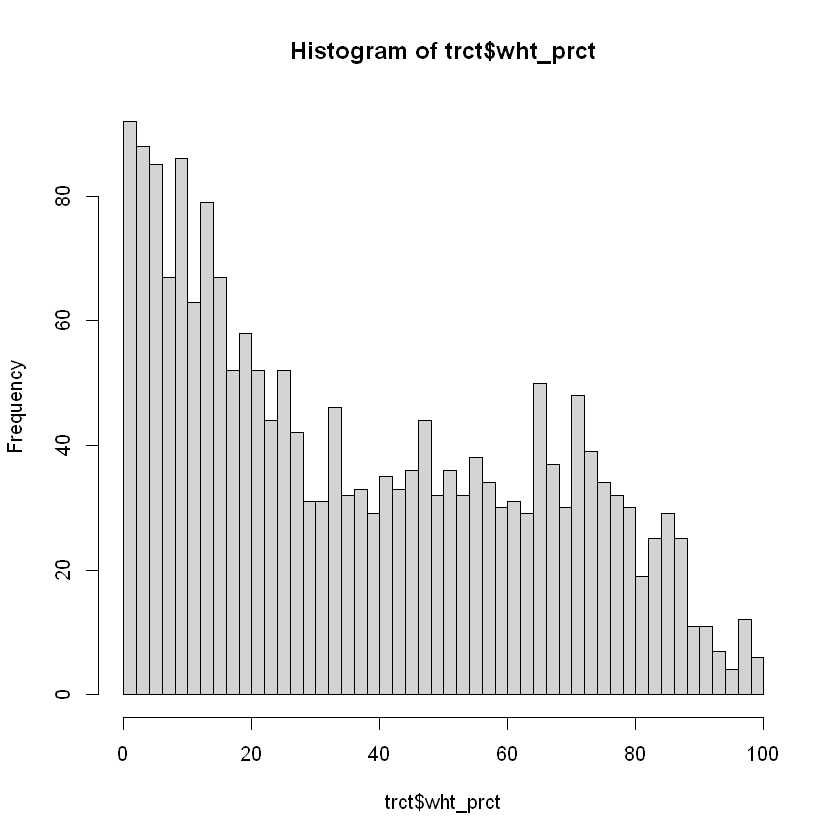

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  0.000   2.263  10.156  24.111  40.861 100.000     176 

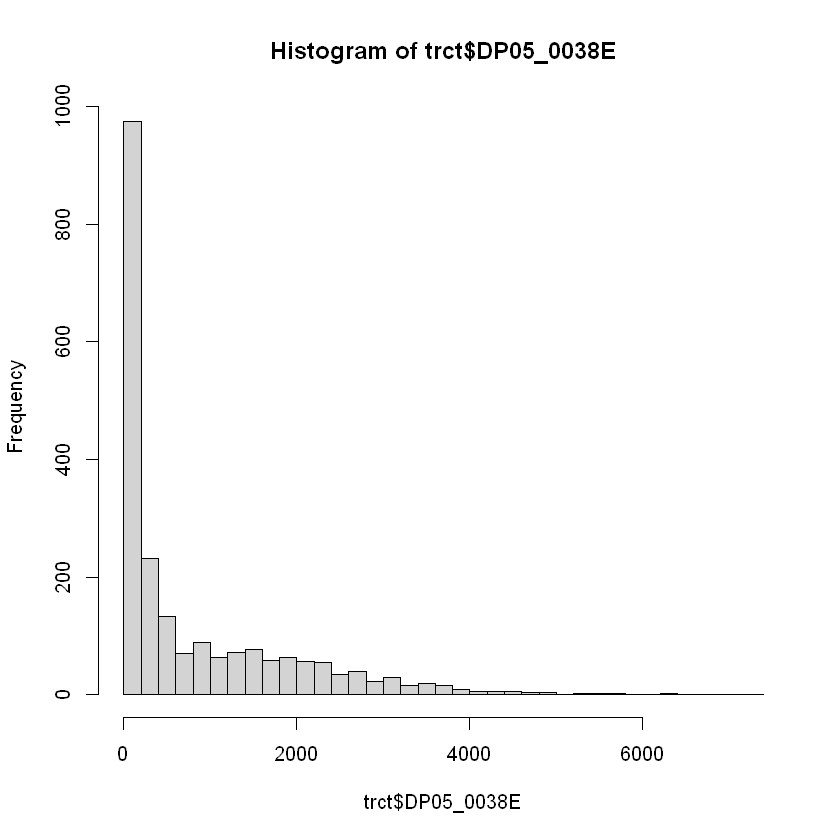

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0    50.0   237.0   510.7   708.5  7248.0 

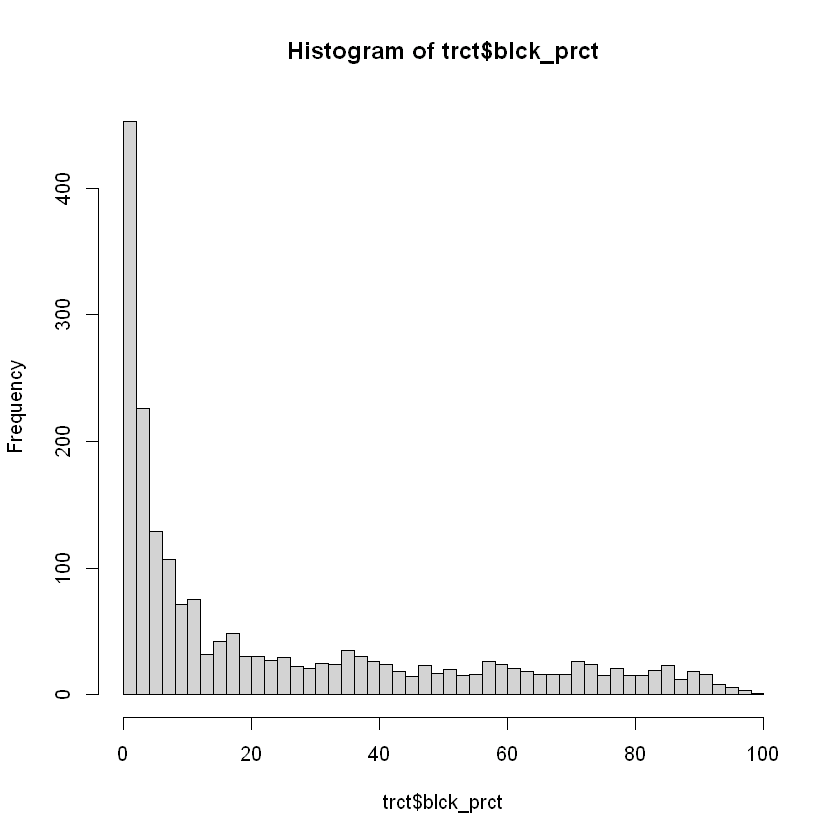

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  0.000   2.776   7.816  14.845  21.325  91.544     176 

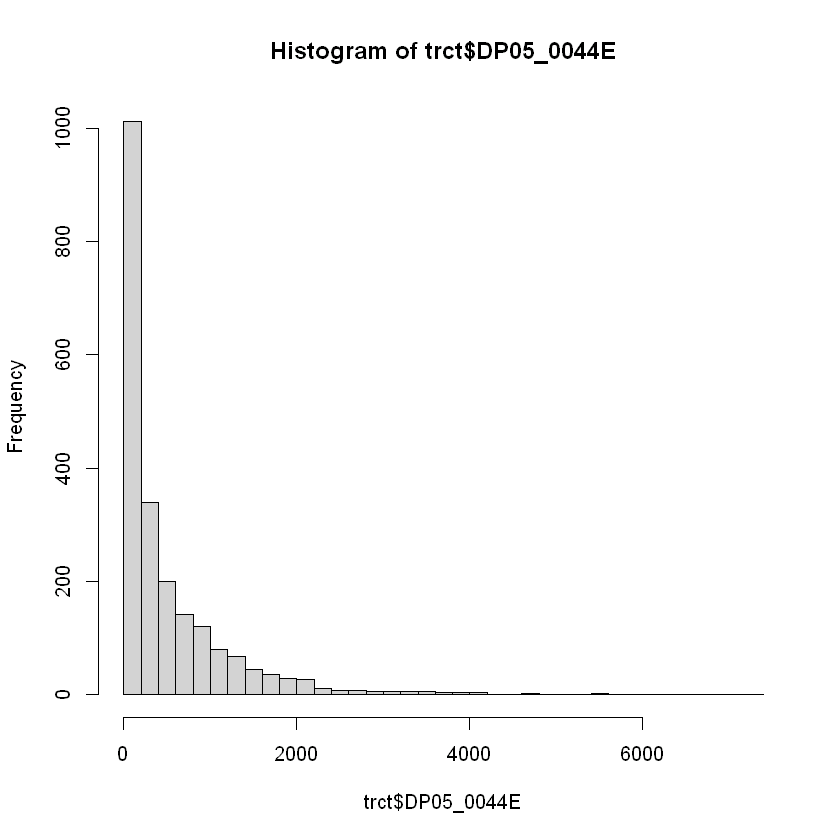

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0   270.8   589.0   910.6  1177.2  9925.0 

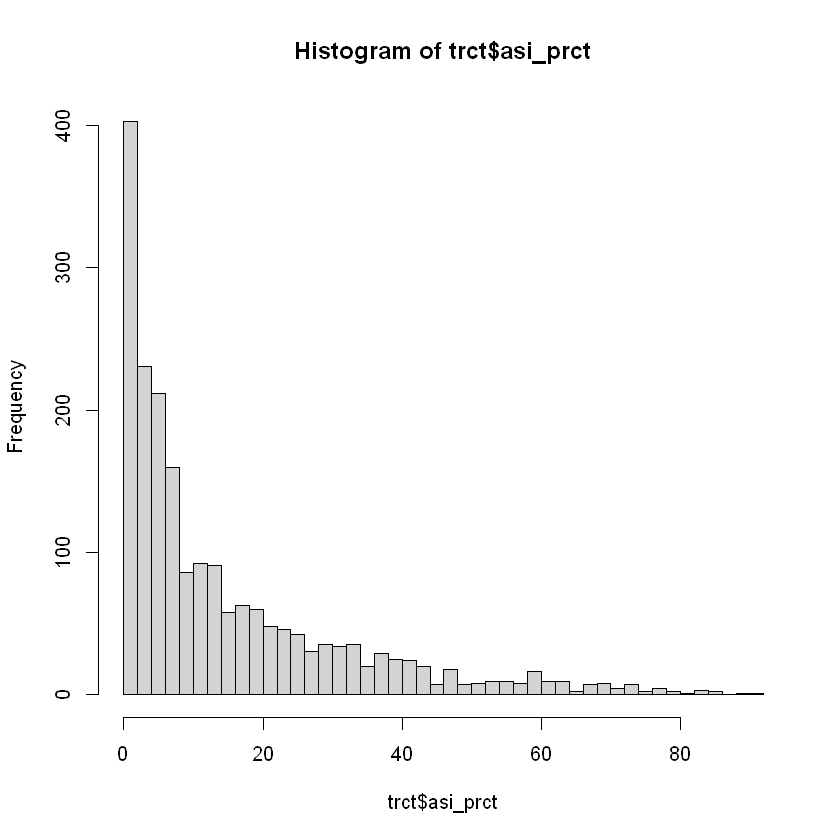

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   0.00   10.79   18.80   23.95   33.99   84.82     176 

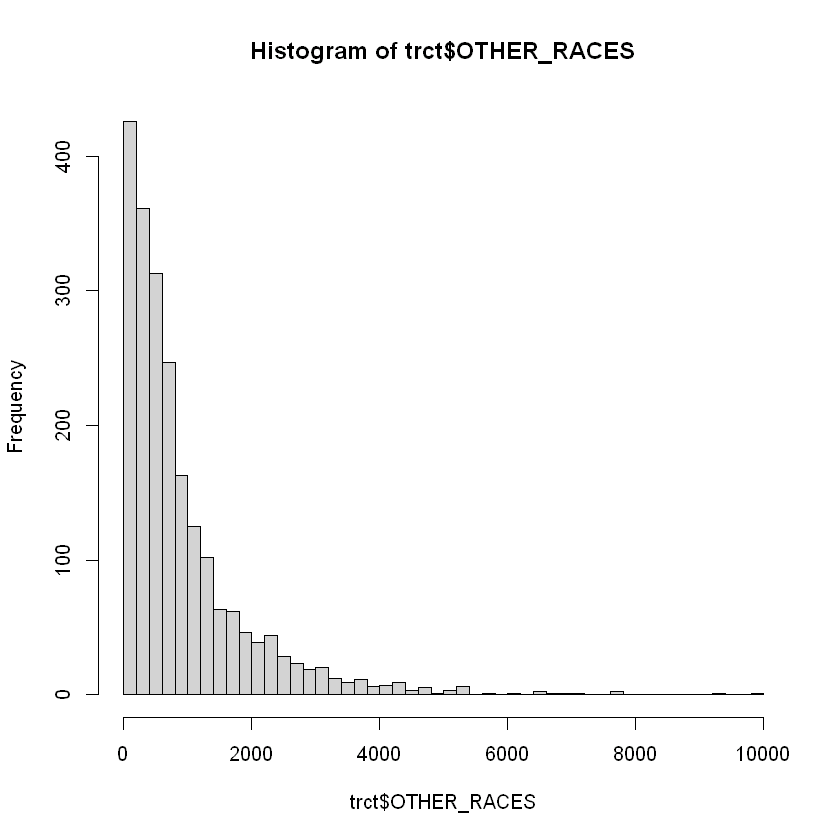

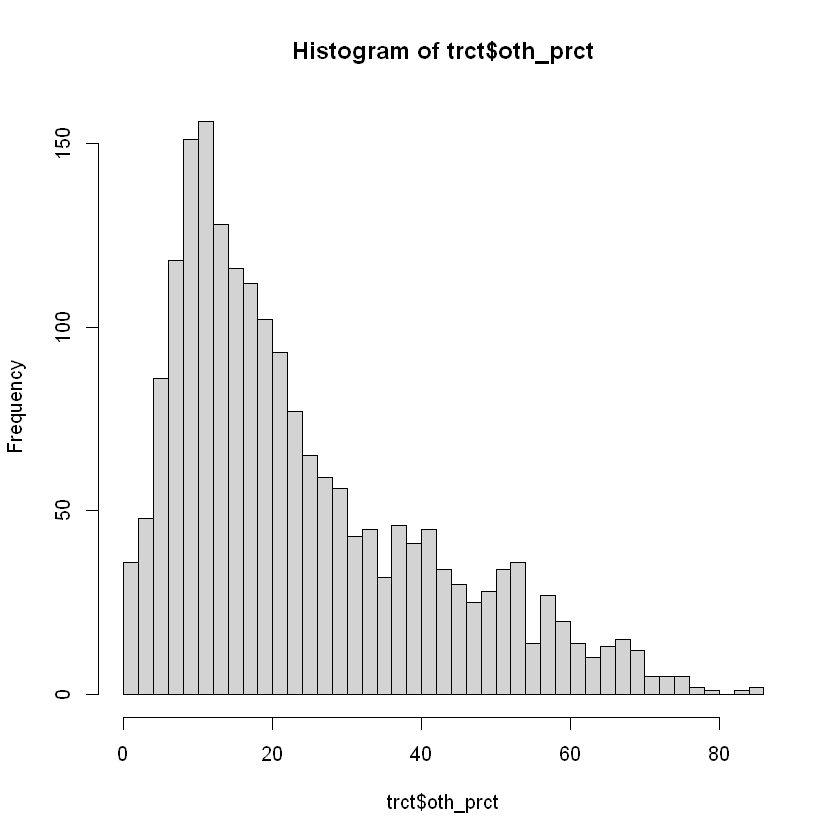

In [16]:
# White
summary(trct$DP05_0037E)
hist(trct$DP05_0037E, breaks = 50)
trct <- mutate(trct, wht_prct = (DP05_0037E / DP05_0033E) * 100)
summary(trct$wht_prct)
hist(trct$wht_prct, breaks = 50)

# Black
summary(trct$DP05_0038E)
hist(trct$DP05_0038E, breaks = 50)
trct <- mutate(trct, blck_prct = (DP05_0038E / DP05_0033E) * 100)
summary(trct$blck_prct)
hist(trct$blck_prct, breaks = 50)

# Asian
summary(trct$DP05_0044E)
hist(trct$DP05_0044E, breaks = 50)
trct <- mutate(trct, asi_prct = (DP05_0044E / DP05_0033E) * 100)
summary(trct$asi_prct)
hist(trct$asi_prct, breaks = 50)

# Other races
summary(trct$OTHER_RACES)
hist(trct$OTHER_RACES, breaks = 50)
trct <- mutate(trct, oth_prct = (OTHER_RACES / DP05_0033E) * 100)
summary(trct$oth_prct)
hist(trct$oth_prct, breaks = 50)

### Hispanic groups

Each Hispanic group will be divided by the Estimate of Population Identifying as Hispanic or Latino (of Any Race) and multiplied by 100.

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0     0.0    39.0   141.4   153.2  2597.0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  0.000   0.000   7.407  13.156  19.789 100.000     185 

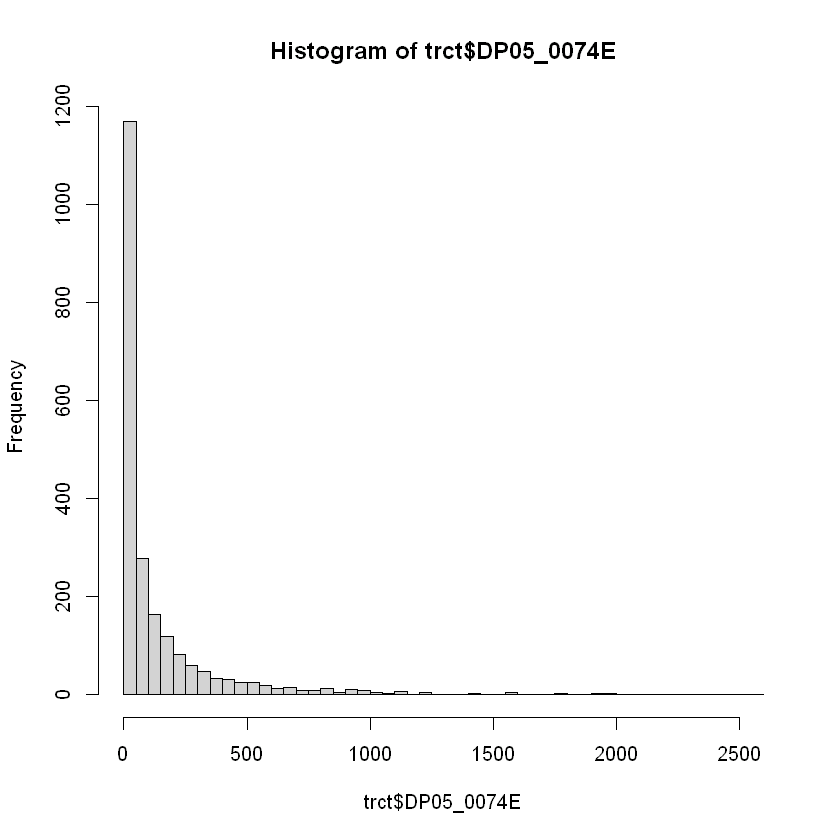

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0    36.0   126.0   273.7   341.0  2748.0 

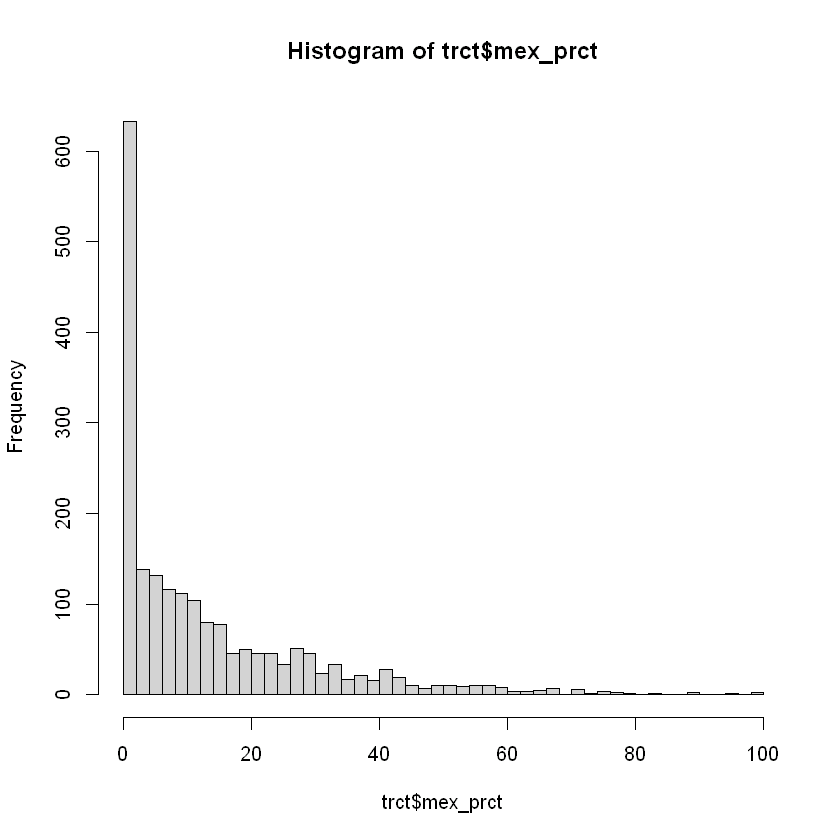

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   0.00   11.75   23.68   27.86   40.01  100.00     185 

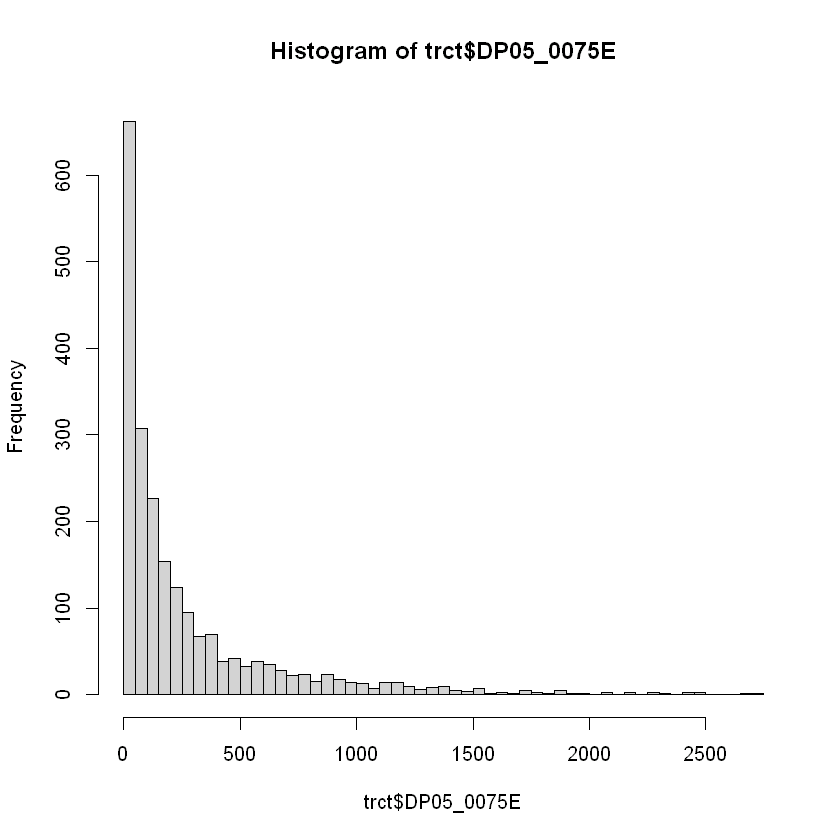

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   0.00    0.00    0.00   17.69   18.00  496.00 

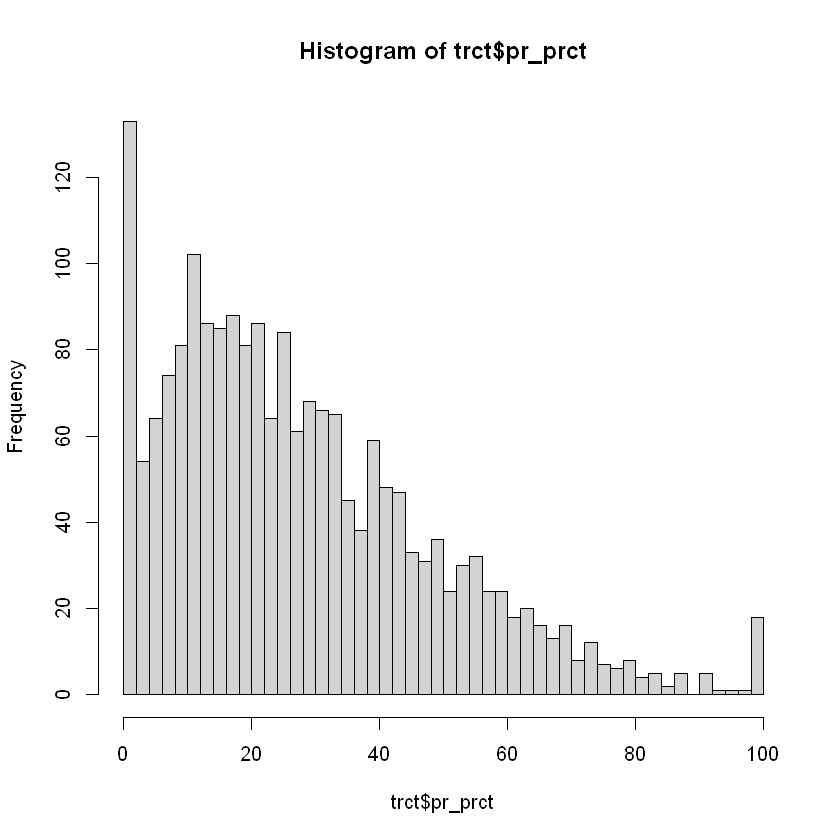

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  0.000   0.000   0.000   2.478   2.266  62.850     185 

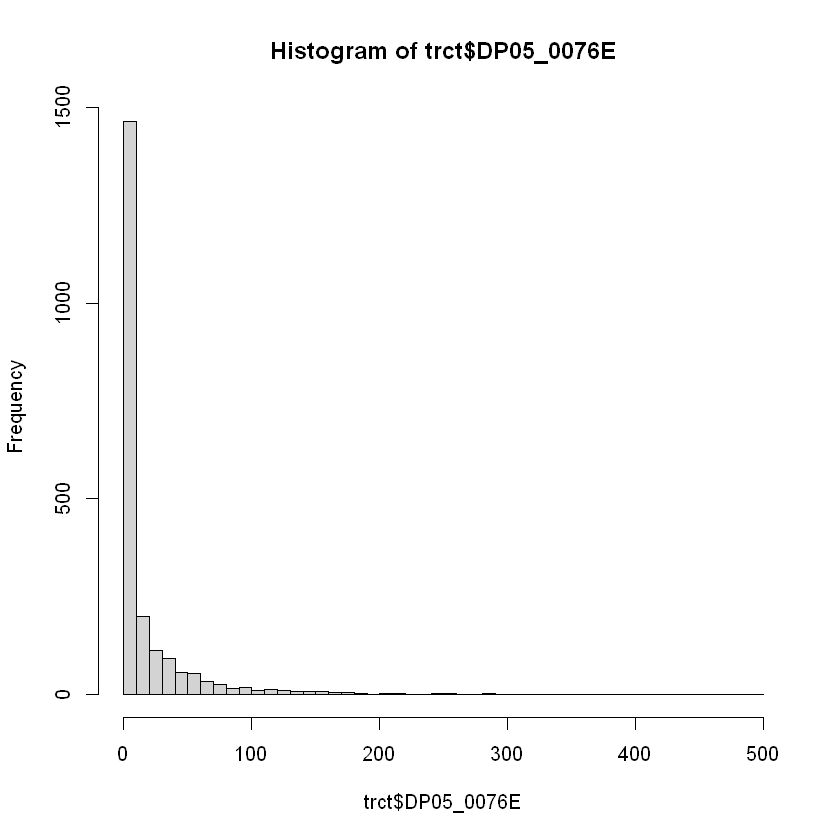

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0   103.5   321.0   623.5   795.2 10844.0 

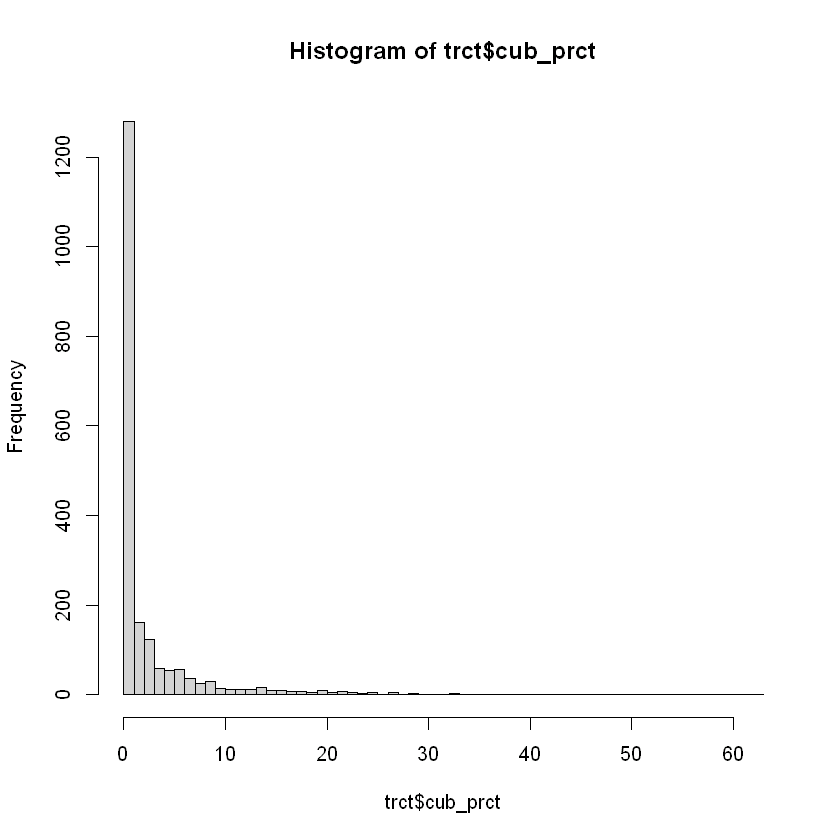

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   0.00   41.44   57.81   56.50   72.60  100.00     185 

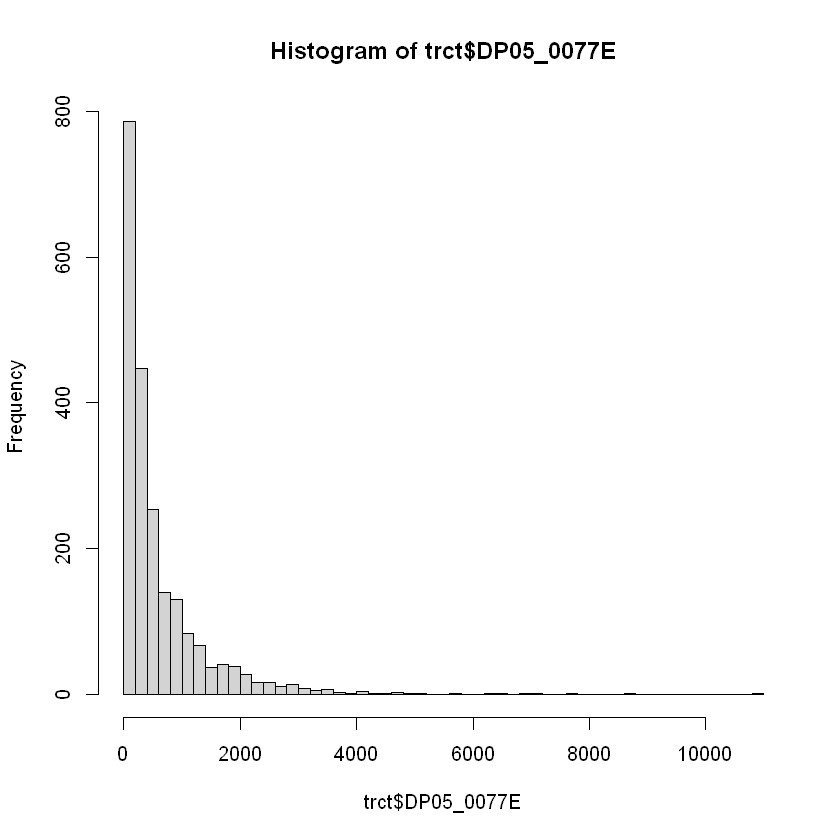

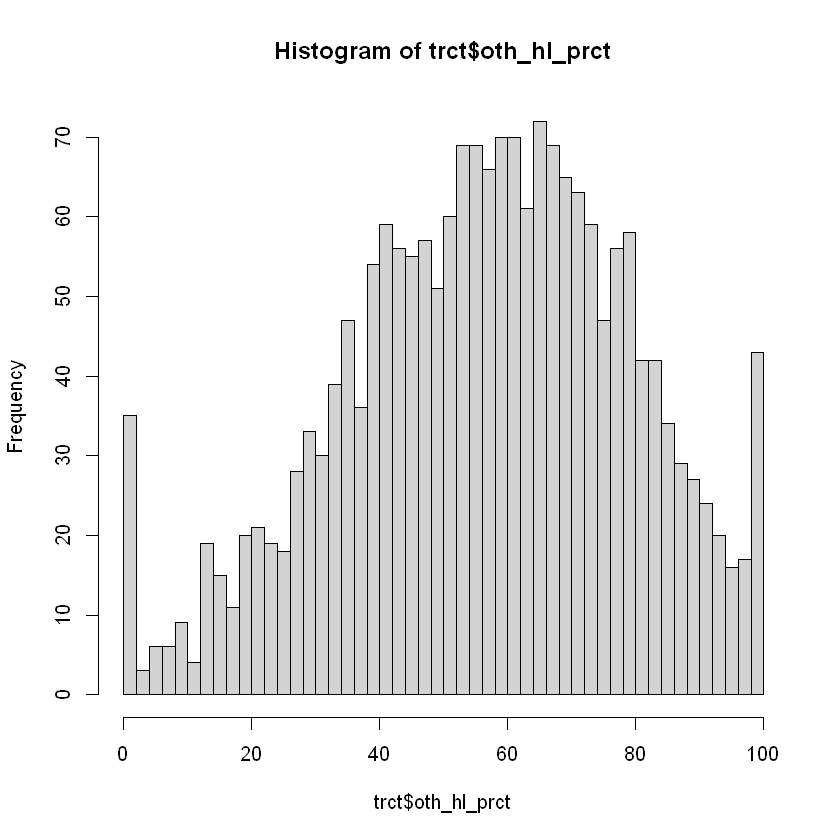

In [17]:
# Mexican
summary(trct$DP05_0074E)
hist(trct$DP05_0074E, breaks = 50)
trct <- mutate(trct, mex_prct = (DP05_0074E / DP05_0073E) * 100)
summary(trct$mex_prct)
hist(trct$mex_prct, breaks = 50)

# Puerto Rican
summary(trct$DP05_0075E)
hist(trct$DP05_0075E, breaks = 50)
trct <- mutate(trct, pr_prct = (DP05_0075E / DP05_0073E) * 100)
summary(trct$pr_prct)
hist(trct$pr_prct, breaks = 50)

# Cuban
summary(trct$DP05_0076E)
hist(trct$DP05_0076E, breaks = 50)
trct <- mutate(trct, cub_prct = (DP05_0076E / DP05_0073E) * 100)
summary(trct$cub_prct)
hist(trct$cub_prct, breaks = 50)

# Other Hispanic
summary(trct$DP05_0077E)
hist(trct$DP05_0077E, breaks = 50)
trct <- mutate(trct, oth_hl_prct = (DP05_0077E / DP05_0073E) * 100)
summary(trct$oth_hl_prct)
hist(trct$oth_hl_prct, breaks = 50)

## 1.8 Ratio

Calculating ratio will help facilitate comparison between groups and enhance the understanding of the data. It also helps with data normalization and identifying disparities. In both cases, race and Hispanic groups will be using the biggest population group as the base.

### Race ratio — white as the base

There is also a filter that helps getting rid of outliers by setting a limit of **200**.

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
0.00000 0.04436 0.28295     Inf 2.84716     Inf     176 

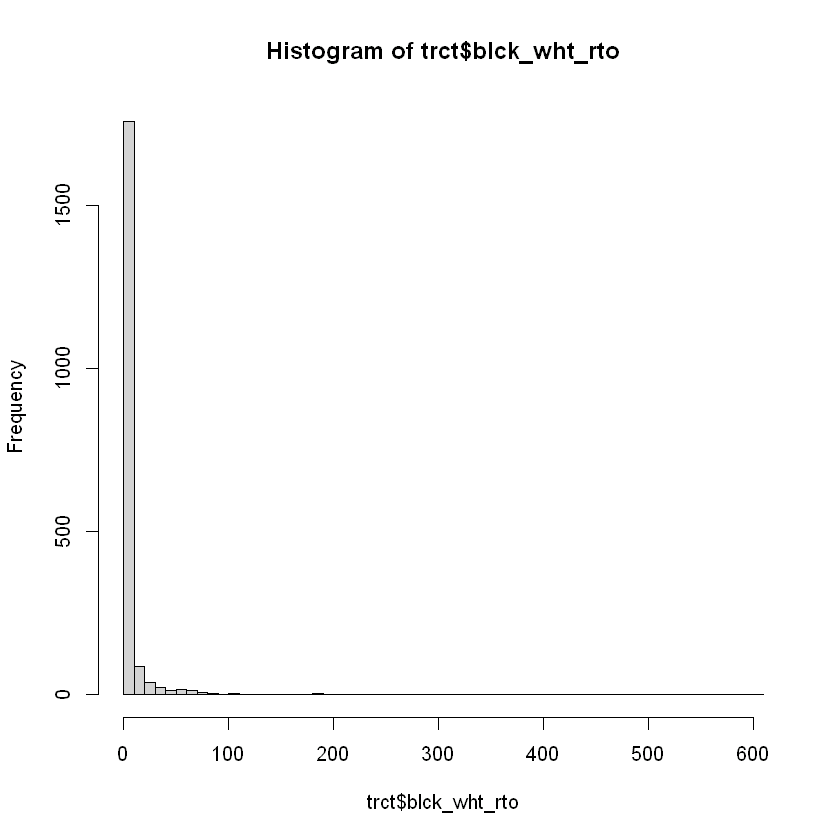

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
0.00000 0.09214 0.25229     Inf 0.73841     Inf     178 

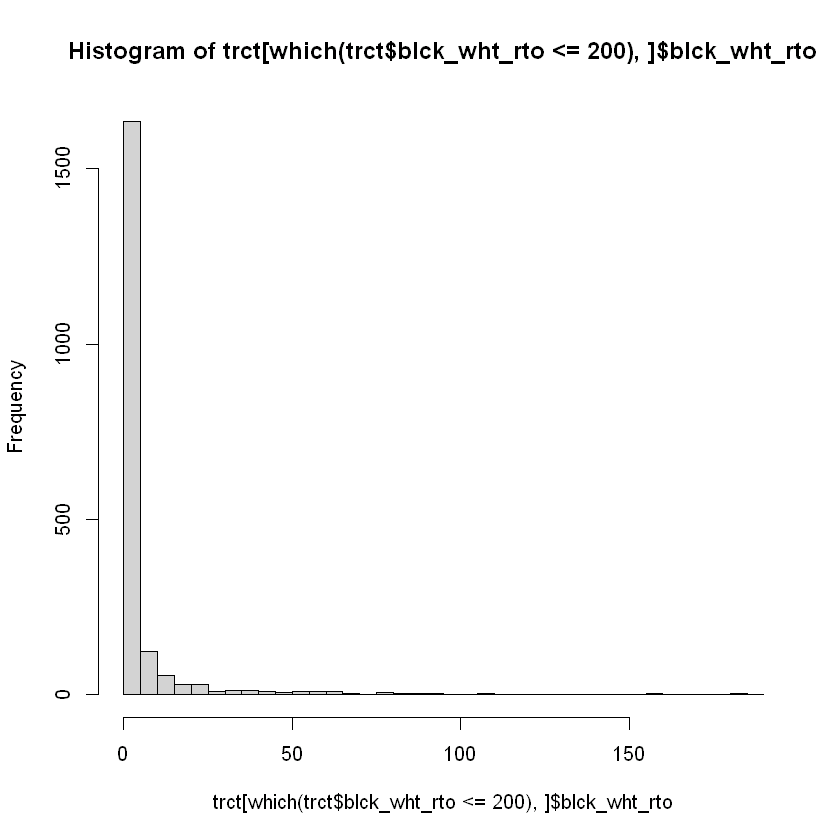

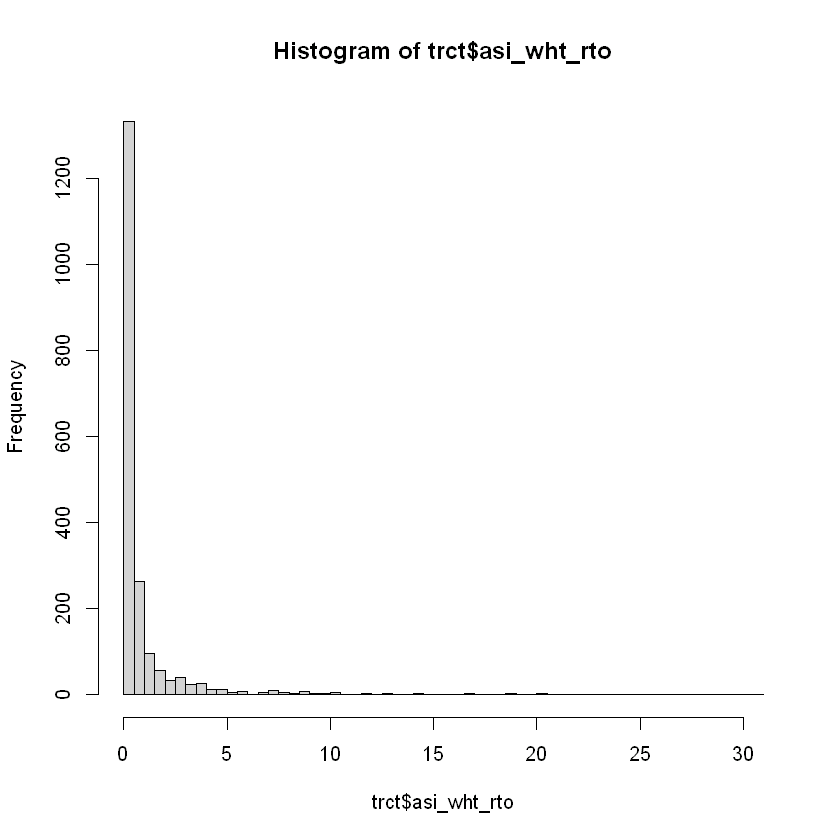

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.0000  0.2317  0.7247     Inf  2.4901     Inf     177 

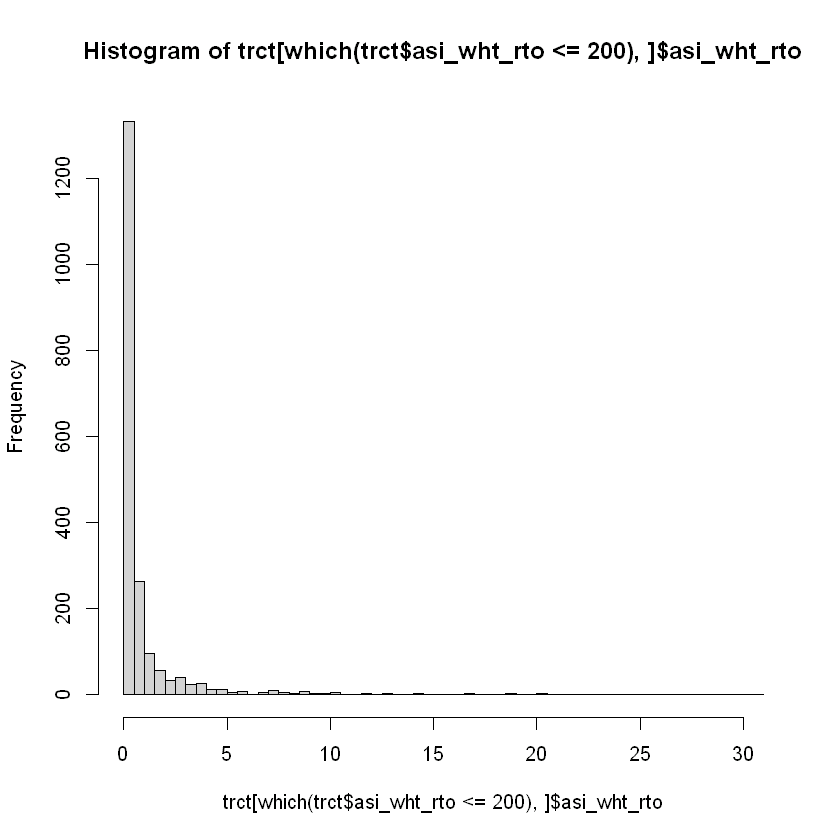

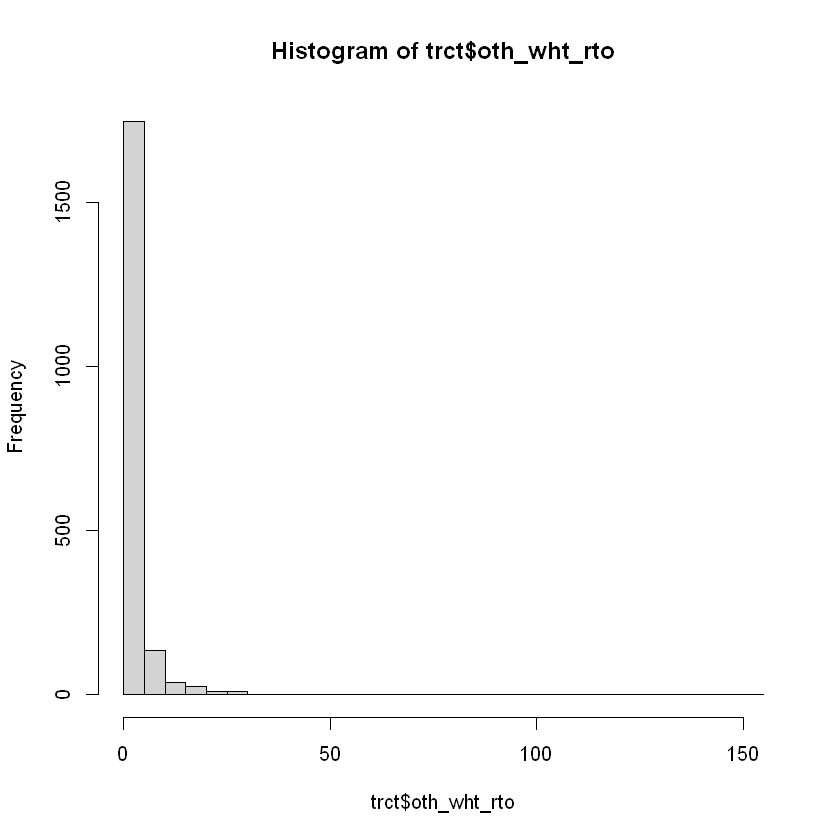

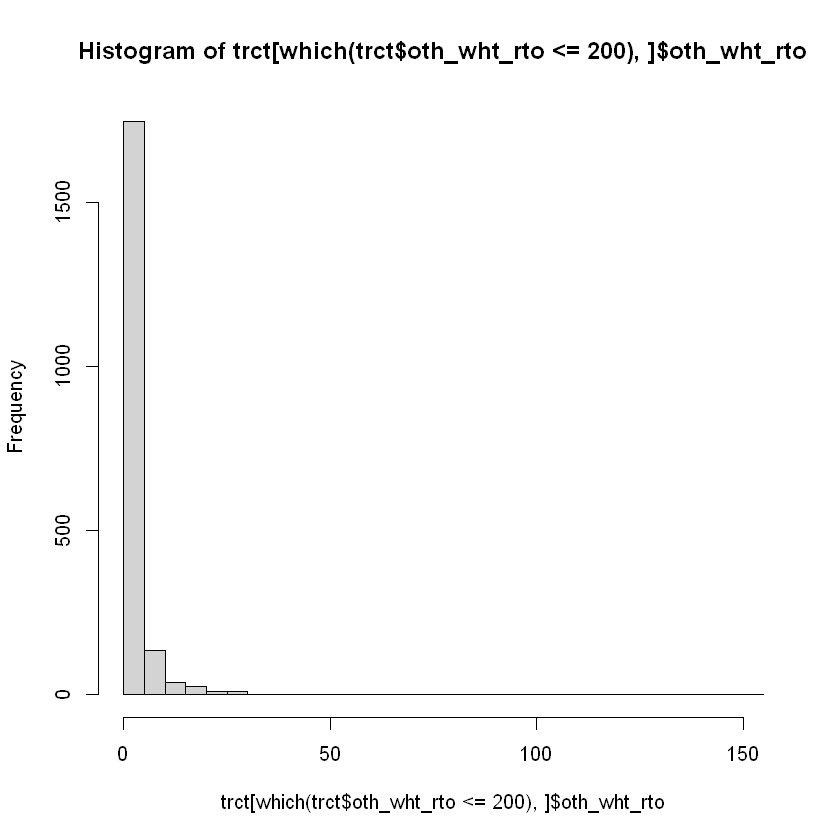

In [18]:
# Black
trct <- mutate(trct, blck_wht_rto = DP05_0038E / DP05_0037E)
summary(trct$blck_wht_rto)
hist(trct$blck_wht_rto, breaks = 50)
hist(trct[which(trct$blck_wht_rto <= 200), ]$blck_wht_rto, breaks = 50) # filter outliers

# Asian
trct <- mutate(trct, asi_wht_rto = DP05_0044E / DP05_0037E)
summary(trct$asi_wht_rto)
hist(trct$asi_wht_rto, breaks = 50)
hist(trct[which(trct$asi_wht_rto <= 200), ]$asi_wht_rto, breaks = 50)

# Other
trct <- mutate(trct, oth_wht_rto = OTHER_RACES / DP05_0037E)
summary(trct$oth_wht_rto)
hist(trct$oth_wht_rto, breaks = 50)
hist(trct[which(trct$oth_wht_rto <= 200), ]$oth_wht_rto, breaks = 50)

### Hispanic ratio — Puerto Rican as the base

For the Hispanic groups ratio, Puerto Rican will be considered as the base due to being the biggest population group.

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
0.00000 0.01226 0.31293     Inf 1.23428     Inf     232 

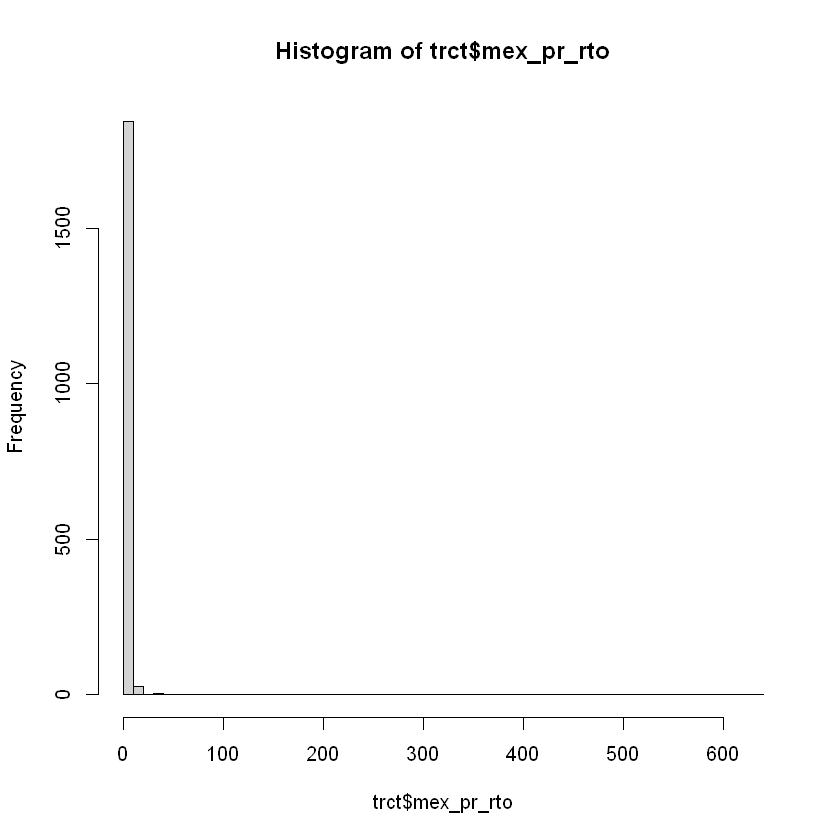

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
 0.0000  0.0000  0.0000     Inf  0.1187     Inf     261 

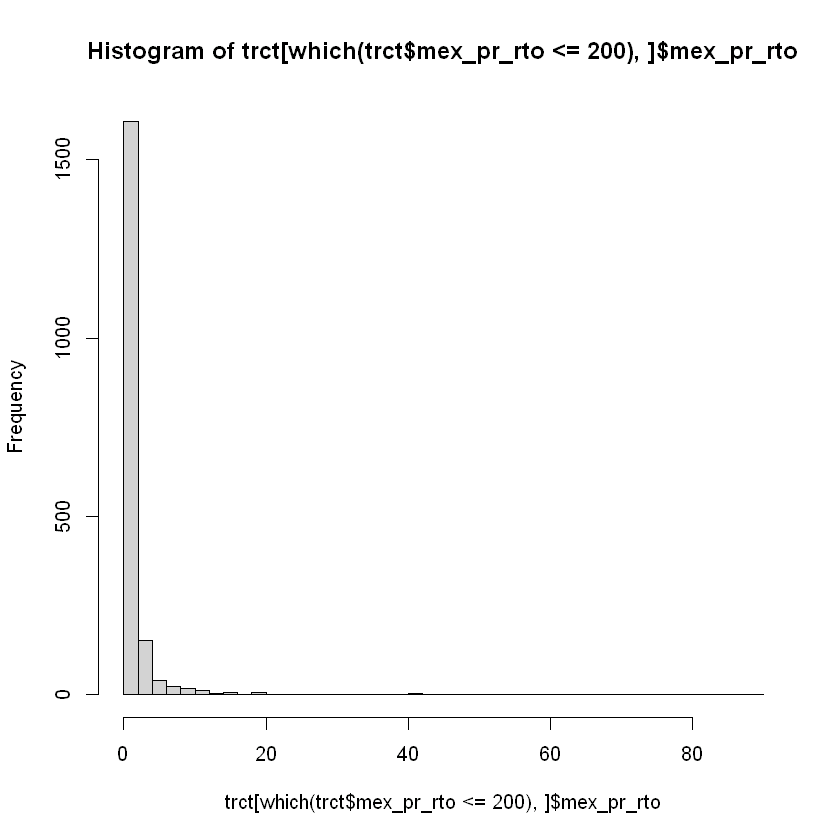

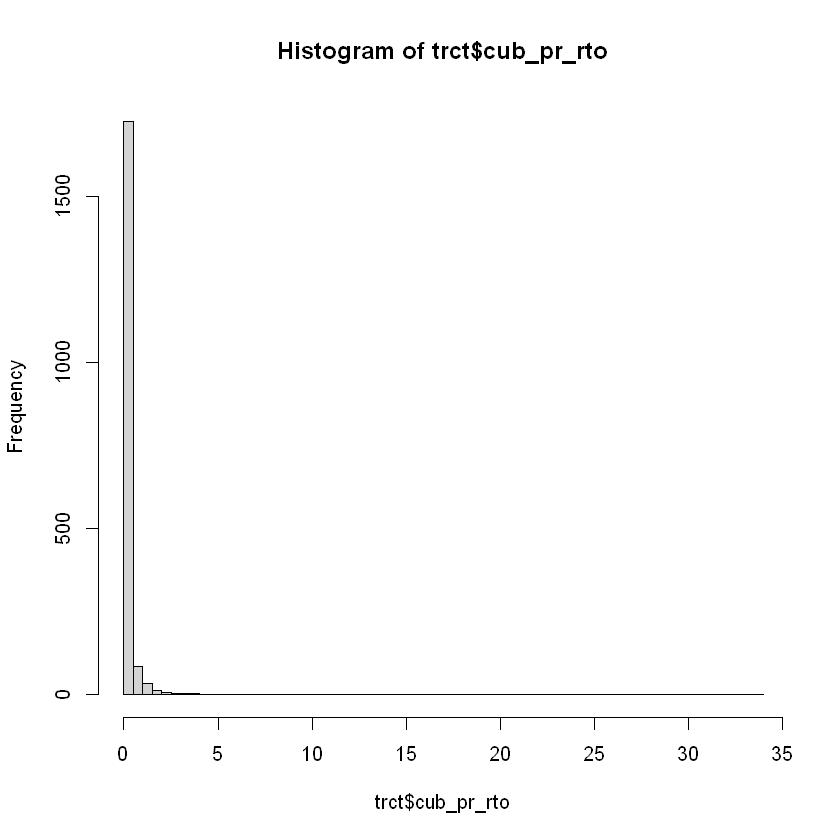

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
  0.000   1.104   2.482     Inf   5.753     Inf     186 

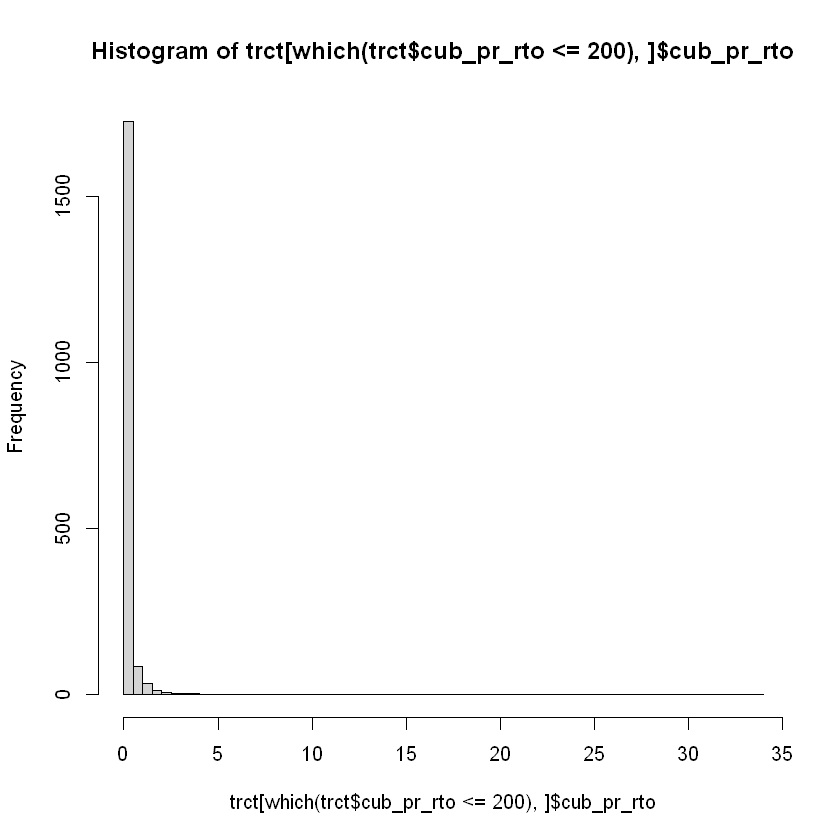

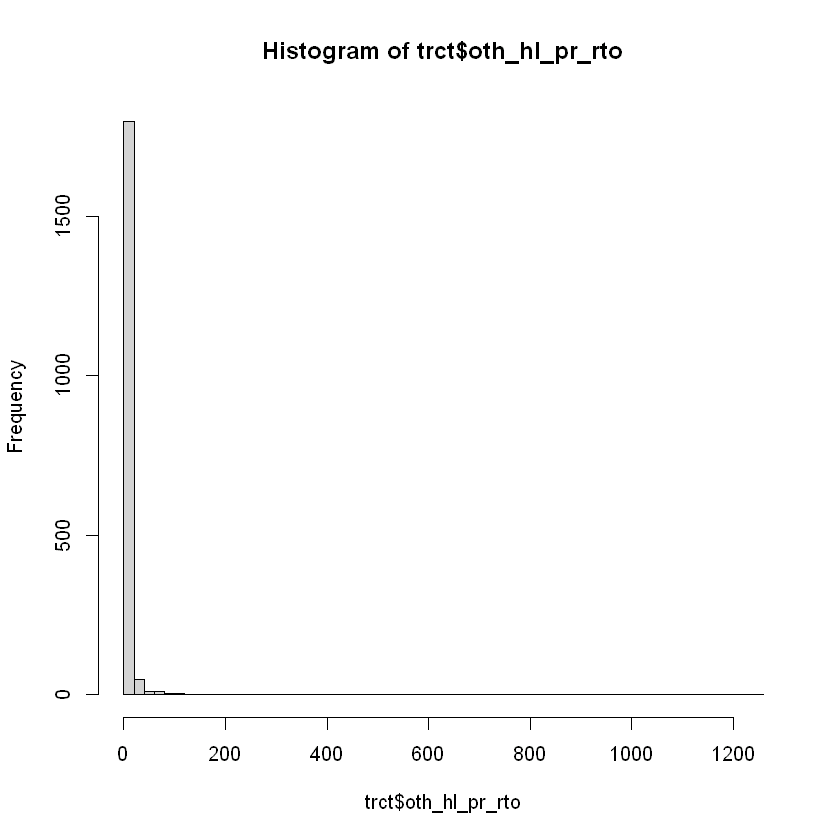

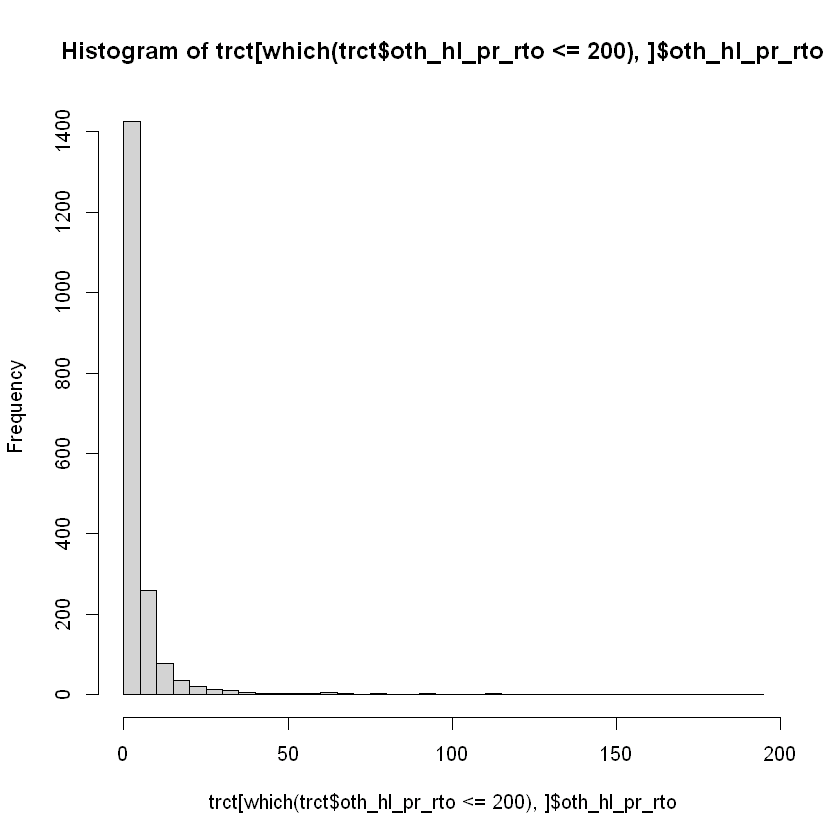

In [19]:
# Mexican
trct <- mutate(trct, mex_pr_rto = DP05_0074E / DP05_0075E)
summary(trct$mex_pr_rto)
hist(trct$mex_pr_rto, breaks = 50)
hist(trct[which(trct$mex_pr_rto <= 200), ]$mex_pr_rto, breaks = 50)

# Cuban
trct <- mutate(trct, cub_pr_rto = DP05_0076E / DP05_0075E)
summary(trct$cub_pr_rto)
hist(trct$cub_pr_rto, breaks = 50)
hist(trct[which(trct$cub_pr_rto <= 200), ]$cub_pr_rto, breaks = 50)

# Other Hispanic
trct <- mutate(trct, oth_hl_pr_rto = DP05_0077E / DP05_0075E)
summary(trct$oth_hl_pr_rto)
hist(trct$oth_hl_pr_rto, breaks = 50)
hist(trct[which(trct$oth_hl_pr_rto <= 200), ]$oth_hl_pr_rto, breaks = 50)

## 1.9 Density

In order to have an estimate of population distribution, we will be calculating the Areal density for each race group by dividing the race population (numerator) by the `ALAND` value (denominator). The `ALAND` value represents land area in square meters.

As density will help us identify many insights, such as spatial patterns or high density regions for specific groups.

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.001266 0.004049 0.006697 0.009187 0.064922 

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.000178 0.001280 0.004418 0.006796 0.050454 

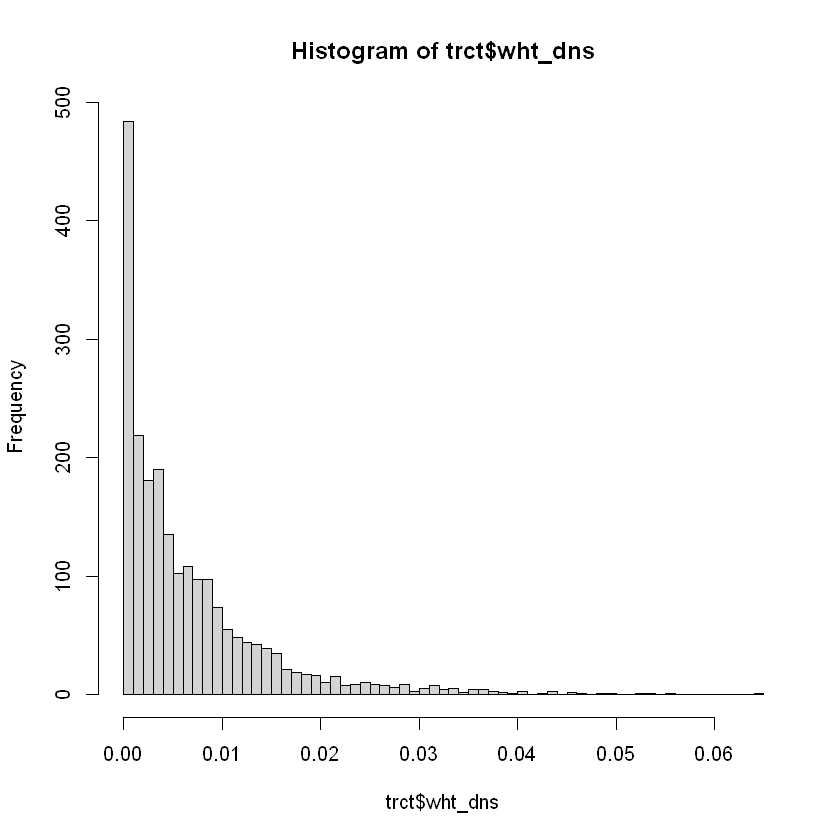

     Min.   1st Qu.    Median      Mean   3rd Qu.      Max. 
0.0000000 0.0002069 0.0011252 0.0024569 0.0032509 0.0476417 

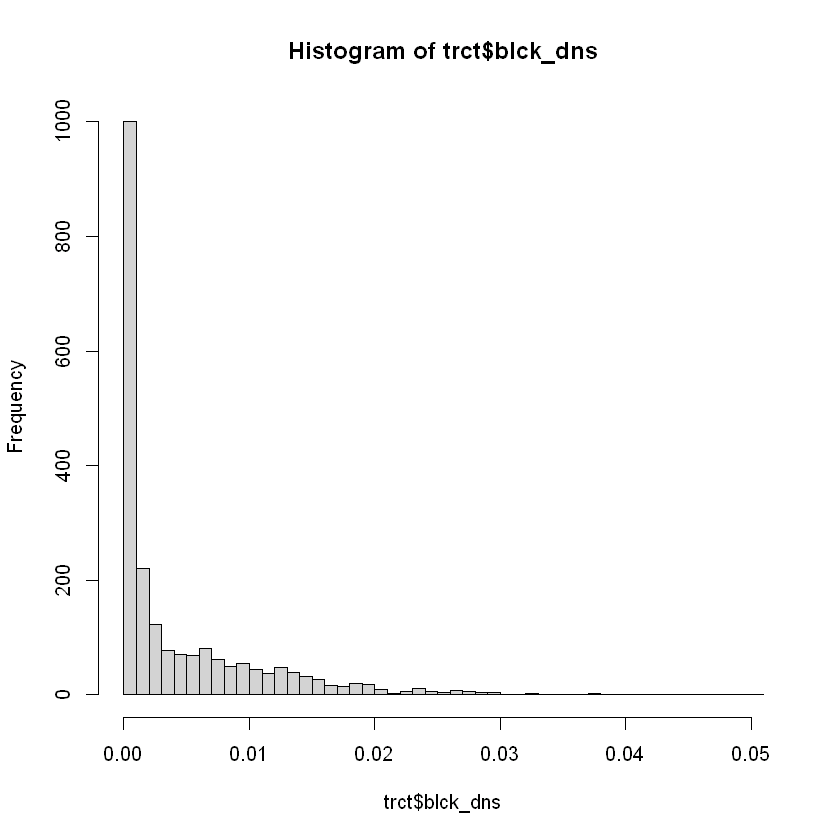

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
0.000000 0.001002 0.002808 0.005115 0.006237 0.066575 

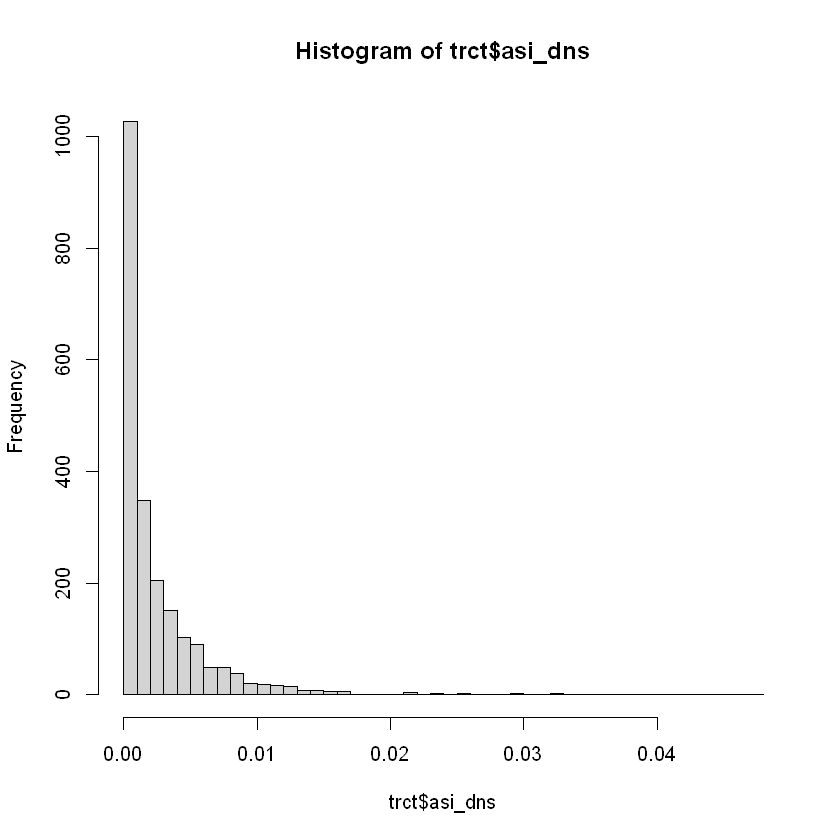

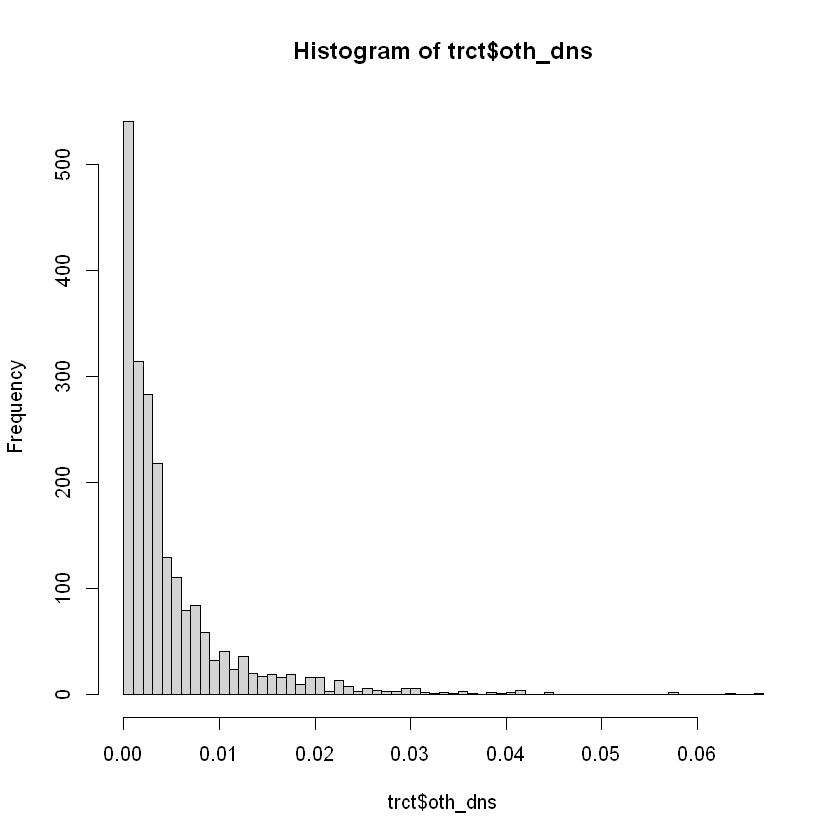

In [20]:
# White
trct <- mutate(trct, wht_dns = DP05_0037E / ALAND)
summary(trct$wht_dns)
hist(trct$wht_dns, breaks = 50)

# Black
trct <- mutate(trct, blck_dns = DP05_0038E / ALAND)
summary(trct$blck_dns)
hist(trct$blck_dns, breaks = 50)

# Asian
trct <- mutate(trct, asi_dns = DP05_0044E / ALAND)
summary(trct$asi_dns)
hist(trct$asi_dns, breaks = 50)

# Other
trct <- mutate(trct, oth_dns = OTHER_RACES / ALAND)
summary(trct$oth_dns)
hist(trct$oth_dns, breaks = 50)

## 1.10 Outputting Data

In order to save the new data frame with the new variables in it, the function `st_write` is used. This allows us to save the data frame `trct` in the `nyc_gpkg` file, letting us assign a new name to this layer. In case a layer with the same name already exists, the function will delete the layer and save this new one.

In [21]:
st_write(trct, dsn = nyc_gpkg, layer = "assignmnt_1", delete_layer = TRUE)

Deleting layer `assignmnt_1' failed
Writing layer `assignmnt_1' to data source 
  `cb_2022_us_tract510_500k_nyc.gpkg' using driver `GPKG'
Writing 2164 features with 66 fields and geometry type Multi Polygon.


---
# Part 2. Location Quotients
---

## 2.1 Introduction

The city of New York is a great place to study many phenomena related to race and ethnicity, with a population of 8,258,035 people. The diversity this city has is something that can not be found in many places around the globe. This makes the city perfect for studies related to segregation and social disparities.

In the next code blocks, R is used to manipulate New York City race census data with the objective of creating a new statistic, the **Location Quotient** which will then be extracted and written as a non spatial layer.

## 2.2 Load the Cleaned Layer

For this part the main layer to work with is **assignmnt_1**, which was saved in Part 1.

In [23]:
layers <- st_layers(nyc_gpkg)
print(layers)

trct_1 <- st_read(nyc_gpkg, layer = "assignmnt_1")
print(head(trct_1))
print(tail(trct_1))

Driver: GPKG 
Available layers:
                        layer_name geometry_type features fields
1    cb_2022_us_county510_500k_nyc       Polygon        7     10
2 cb_2022_us_tract510_500k_nyc_v2b Multi Polygon     2164     47
3                      assignmnt_1 Multi Polygon     2164     66
                               crs_name
1 North_America_Albers_Equal_Area_Conic
2 North_America_Albers_Equal_Area_Conic
3 North_America_Albers_Equal_Area_Conic
Reading layer `assignmnt_1' from data source 
  `C:\Users\REDGA\Downloads\cb_2022_us_tract510_500k_nyc.gpkg' 
  using driver `GPKG'
Simple feature collection with 2164 features and 66 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 1718547 ymin: 256723.3 xmax: 1756681 ymax: 311508
Projected CRS: North_America_Albers_Equal_Area_Conic
Simple feature collection with 6 features and 66 fields
Geometry type: MULTIPOLYGON
Dimension:     XY
Bounding box:  xmin: 1735824 ymin: 284988.8 xmax: 1746260 ymax: 294037.6
Projected CR

In [24]:
names(trct_1)  # list the attributes.
str(trct_1)    # list the attribute data types.
ncol(trct_1)   # number of columns

[1] "OBJECTID"      "STATEFP"       "COUNTYFP"      "TRACTCE"      
 [5] "GEOID"         "NAME"          "NAMELSAD"      "MTFCC"        
 [9] "FUNCSTAT"      "ALAND"         "AWATER"        "INTPTLAT"     
[13] "INTPTLON"      "GEOID_TRACT"   "CNT_BLK_GRP"   "GEO_ID"       
[17] "LABLE"         "STATE_FIPS"    "COUNTY_FIPS"   "TRACT_FIPS"   
[21] "DP05_0033E"    "DP05_0037E"    "DP05_0038E"    "DP05_0039E"   
[25] "DP05_0044E"    "DP05_0052E"    "DP05_0057E"    "DP05_0058E"   
[29] "DP05_0072E"    "DP05_0073E"    "DP05_0074E"    "DP05_0075E"   
[33] "DP05_0076E"    "DP05_0077E"    "DP05_0078E"    "DP05_0079E"   
[37] "DP05_0080E"    "DP05_0081E"    "DP05_0082E"    "DP05_0083E"   
[41] "DP05_0084E"    "DP05_0085E"    "DP05_5758E"    "DP05_0037P"   
[45] "DP05_0038P"    "DP05_0044P"    "DP05_3958P"    "OTHER_RACES"  
[49] "wht_prct"      "blck_prct"     "asi_prct"      "oth_prct"     
[53] "mex_prct"      "pr_prct"       "cub_prct"      "oth_hl_prct"  
[57] "blck_wht_rto"  "asi_wht_rto"   "oth_wht_rto"   "mex_pr_rto"   
[61] "cub_pr_rto"    "oth_hl_pr_rto" "wht_dns"       "blck_dns"     
[65] "asi_dns"       "oth_dns"       "geom"

Classes 'sf' and 'data.frame':	2164 obs. of  67 variables:
 $ OBJECTID     : num  1 2 3 4 5 6 7 8 9 10 ...
 $ STATEFP      : chr  "36" "36" "36" "36" ...
 $ COUNTYFP     : chr  "081" "081" "081" "081" ...
 $ TRACTCE      : chr  "003400" "003900" "003600" "003700" ...
 $ GEOID        : chr  "36081003400" "36081003900" "36081003600" "36081003700" ...
 $ NAME         : chr  "34" "39" "36" "37" ...
 $ NAMELSAD     : chr  "Census Tract 34" "Census Tract 39" "Census Tract 36" "Census Tract 37" ...
 $ MTFCC        : chr  "G5020" "G5020" "G5020" "G5020" ...
 $ FUNCSTAT     : chr  "S" "S" "S" "S" ...
 $ ALAND        : num  213987 146970 180006 386629 176214 ...
 $ AWATER       : num  0 0 0 14591 0 ...
 $ INTPTLAT     : chr  "+40.6847731" "+40.7627994" "+40.6837714" "+40.7624148" ...
 $ INTPTLON     : chr  "-073.8581871" "-073.9409316" "-073.8568176" "-073.9434494" ...
 $ GEOID_TRACT  : chr  "36081003400" "36081003900" "36081003600" "36081003700" ...
 $ CNT_BLK_GRP  : int  2 2 1 3 1 2 1 2 1 2 ..

[1] 67

## 2.3 Data Preparation

In order to create the new statistic (Location Quotient), a list of four demographic groups is needed. The list used here was formed by the 4 different race groups: white, black, Asian and other races.

Having a list facilitates the function process by calling just the list instead of each race group separately.

In [25]:
race_groups <- c("DP05_0037E", "DP05_0038E", "DP05_0044E", "OTHER_RACES")

In the next code chunk a summary of each race group within the list is printed. The `summary()` function helps better understand the data by providing relevant statistics like Min, Mean, Median, Max, 1st quartile and 3rd quartile.

In [26]:
group_summary <- function(data, columns) {
  for (column in columns) {
    cat("Summary for", column, ":\n")
    print(summary(data[[column]]))
    cat("\n") # Print a new line for better readability
  }
}

group_summary(trct_1, race_groups)

Summary for DP05_0037E :
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0   265.8   930.5  1342.5  1906.5 12272.0 

Summary for DP05_0038E :
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0    42.0   282.0   830.9  1358.8  7338.0 

Summary for DP05_0044E :
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0    50.0   237.0   510.7   708.5  7248.0 

Summary for OTHER_RACES :
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
    0.0   270.8   589.0   910.6  1177.2  9925.0 



## 2.4 Location Quotient

### Section 1; What is the Location Quotient?

The location quotient is a ratio used to compare the concentration of a particular category in a specific area to a total referenced area. For this analysis the category is racial demographics in the city of New York.

The location quotient is similar to other statistics like percentage, density and ratio in comparing demographics. But a big difference is that while the last three analyze the data within a particular area, the location quotient provides results of a specific area **in relation to a larger population**, in this case, all of New York City. This makes it a convenient tool to understand community dynamics and trends, identifying areas where a group is over or under represented.

The Location Quotient is calculated as:

$$LQ(O_{ti}) = \frac{l_{Oti} / l_{Ati}}{\sum R_O / \sum R_A}$$

Where:
- $LQ(O_{ti})$: is the location quotient of a race group within the tract
- $l_{Oti}$: is the population of the race group in a specific tract
- $l_{Ati}$: is the total population of all race groups in a specific tract
- $\sum R_O$: is the total population of the race group across all tracts
- $\sum R_A$: is the total population of all race groups across all tracts

A result of **1** means equal proportion relative to the city average. **Greater than 1** means over-represented; **less than 1** means under-represented.

### Section 2; Computing the LQ

In [27]:
calculate_lq_and_add <- function(data, group_cols, total_col) {

  for (group_col in group_cols) {

    # lgt_i: Number of Group in tract i (specific group column)
    lgt_i <- data[[group_col]]

    # lAt_i: Total of All Groups in tract i (total population column)
    lAt_i <- data[[total_col]]

    # sigma_tn_Rg: Total number of Group in all tracts (sum of the group column)
    sigma_tn_Rg <- sum(lgt_i, na.rm = TRUE)

    # sigma_tn_RA: Total All Groups in all tracts (sum of the total population column)
    sigma_tn_RA <- sum(lAt_i, na.rm = TRUE)

    # Calculate LQ for each tract
    lq <- (lgt_i / lAt_i) / (sigma_tn_Rg / sigma_tn_RA)

    # Add the LQ column to the original data, appending '_LQ' to the column name
    data[[paste0(group_col, "_LQ")]] <- lq
  }

  return(data) # Return the updated dataset
}

Once the function is created the arguments to input them in the function are prepared.

The first thing to consider is making sure that the list does not have a geometry column attached to it. In order to achieve this, the `st_drop_geometry()` function is used.

> **Note:** The geometry column is an important part of spatial dataframes (sf objects). When subsetting an sf object the geometry column remains attached. This would cause problems during calculations since only numerical values can go through them, which is the reason why dropping the geometry is needed here.

In [28]:
# Remove the geometry column to allow rowSums calculation
race_data_no_geom <- st_drop_geometry(trct_1[race_groups])

# Create a total population column summing all four race groups per tract
trct_1$total_pop <- rowSums(race_data_no_geom, na.rm = TRUE)

# Apply the LQ function
trct_1 <- calculate_lq_and_add(trct_1, group_cols = race_groups, total_col = "total_pop")

### Assessing the Function Calculation

In order to verify if the variables were created successfully, he structure of `trct_1` was checked and manually verified the LQ calculation for one tract.

In [29]:
# Check the structure of trct_1
str(trct_1)

# Check the calculation for one tract (the first row)
trct_1$total_pop[1] == sum(
  trct_1$DP05_0037E[1], trct_1$DP05_0038E[1],
  trct_1$DP05_0044E[1], trct_1$OTHER_RACES[1],
  na.rm = TRUE
)

Classes 'sf' and 'data.frame':	2164 obs. of  72 variables:
 $ OBJECTID      : num  1 2 3 4 5 6 7 8 9 10 ...
 $ STATEFP       : chr  "36" "36" "36" "36" ...
 $ COUNTYFP      : chr  "081" "081" "081" "081" ...
 $ TRACTCE       : chr  "003400" "003900" "003600" "003700" ...
 $ GEOID         : chr  "36081003400" "36081003900" "36081003600" "36081003700" ...
 $ NAME          : chr  "34" "39" "36" "37" ...
 $ NAMELSAD      : chr  "Census Tract 34" "Census Tract 39" "Census Tract 36" "Census Tract 37" ...
 $ MTFCC         : chr  "G5020" "G5020" "G5020" "G5020" ...
 $ FUNCSTAT      : chr  "S" "S" "S" "S" ...
 $ ALAND         : num  213987 146970 180006 386629 176214 ...
 $ AWATER        : num  0 0 0 14591 0 ...
 $ INTPTLAT      : chr  "+40.6847731" "+40.7627994" "+40.6837714" "+40.7624148" ...
 $ INTPTLON      : chr  "-073.8581871" "-073.9409316" "-073.8568176" "-073.9434494" ...
 $ GEOID_TRACT   : chr  "36081003400" "36081003900" "36081003600" "36081003700" ...
 $ CNT_BLK_GRP   : int  2 2 1 3

[1] TRUE

In [30]:
# Manually calculate LQ for the white population in the first tract to verify
white_pop_tract1       <- trct_1$DP05_0037E[1]
total_pop_tract1       <- trct_1$total_pop[1]
total_white_pop_region <- sum(trct_1$DP05_0037E, na.rm = TRUE)
total_pop_region       <- sum(trct_1$total_pop, na.rm = TRUE)

LQ_white_tract1 <- (white_pop_tract1 / total_pop_tract1) / (total_white_pop_region / total_pop_region)

cat("Manual LQ for whites in first tract:", LQ_white_tract1, "\n")
cat("LQ in dataset:                       ", trct_1$DP05_0037E_LQ[1], "\n")

Manual LQ for whites in first tract: 0.3714664 
LQ in dataset:                        0.3714664 


## 2.5 Writing the Output to the GeoPackage

In order to create a data frame with the new Location Quotient variables and the GEO_ID, the columns of interest are subset. This subset is then written to the GeoPackage as a non spatial layer for future use in QGIS.

In [31]:
lq_df <- trct_1[, c("GEO_ID", "DP05_0037E_LQ", "DP05_0038E_LQ", "DP05_0044E_LQ", "OTHER_RACES_LQ")]
str(lq_df)

Classes 'sf' and 'data.frame':	2164 obs. of  6 variables:
 $ GEO_ID        : chr  "1400000US36081003400" "1400000US36081003900" "1400000US36081003600" "1400000US36081003700" ...
 $ DP05_0037E_LQ : num  0.371 0.882 0.487 NaN 0.64 ...
 $ DP05_0038E_LQ : num  0.462 0.422 0.166 NaN 0.478 ...
 $ DP05_0044E_LQ : num  1.287 0.662 2.238 NaN 1.697 ...
 $ OTHER_RACES_LQ: num  2.26 1.89 1.82 NaN 1.62 ...
 $ geom          :sfc_MULTIPOLYGON of length 2164; first list element: List of 1
  ..$ :List of 1
  .. ..$ : num [1:58, 1:2] 1745500 1745438 1745378 1745320 1745261 ...
  ..- attr(*, "class")= chr [1:3] "XY" "MULTIPOLYGON" "sfg"
 - attr(*, "sf_column")= chr "geom"
 - attr(*, "agr")= Factor w/ 3 levels "constant","aggregate",..: NA NA NA NA NA
  ..- attr(*, "names")= chr [1:5] "GEO_ID" "DP05_0037E_LQ" "DP05_0038E_LQ" "DP05_0044E_LQ" ...


In [33]:
# Drop geometry before writing as a non spatial table
lq_df_no_geom <- st_drop_geometry(lq_df)
str(lq_df_no_geom)

# Check for null values in the GEO_ID column
sum(is.na(lq_df_no_geom$GEO_ID))

'data.frame':	2164 obs. of  5 variables:
 $ GEO_ID        : chr  "1400000US36081003400" "1400000US36081003900" "1400000US36081003600" "1400000US36081003700" ...
 $ DP05_0037E_LQ : num  0.371 0.882 0.487 NaN 0.64 ...
 $ DP05_0038E_LQ : num  0.462 0.422 0.166 NaN 0.478 ...
 $ DP05_0044E_LQ : num  1.287 0.662 2.238 NaN 1.697 ...
 $ OTHER_RACES_LQ: num  2.26 1.89 1.82 NaN 1.62 ...


[1] 131

In [35]:
# Write non spatial LQ subset to GeoPackage
st_write(
  lq_df_no_geom,
  dsn          = nyc_gpkg,
  layer        = "LQ_Subset",
  append       = FALSE,
  driver       = "GPKG",
  layer_options = "ASpatialTable=YES"
)

Deleting layer `LQ_Subset' using driver `GPKG'
Writing layer `LQ_Subset' to data source 
  `cb_2022_us_tract510_500k_nyc.gpkg' using driver `GPKG'
options:        ASpatialTable=YES 


Warning message in CPL_write_ogr(obj, dsn, layer, driver, as.character(dataset_options), :
"GDAL Message 6: dataset cb_2022_us_tract510_500k_nyc.gpkg does not support layer creation option ASpatialTable"


Writing 2164 features with 5 fields without geometries.


---
# Part 3.  Redfin Investor Housing Data
---

## 3.1 Introduction

This part adds a second data source to the analysis: **Redfin 2023 investor housing estimates** for New York City. By joining this data to the census tract geography, the relationship between investor home purchasing activity and the demographic composition of neighborhoods can be spatially analyzed.

The Redfin dataset comes in two files:

- **`rfin_2023_nyc_investor_market_estimates.csv`**  Census tract level: median list price, sales price, homes sold, new listings, and inventory estimates.
- **`rfin_2023_nyc_investor_purchase_estimates.csv`**  Census tract level: percentage of homes purchased by investors (`pct_invst`), number of investor purchases, total home sales, and ratio of sales to investor purchases.

The key variable for the spatial analysis is `pct_invst`  the **percentage of all home sales purchased by investors**.

## 3.2 Load and Explore the Redfin Data

In [37]:
# Load both Redfin CSVs
rfin_market    <- read.csv("C:/Users/REDGA/Downloads/rfin_2023_nyc_investor_market_estimates.csv")
rfin_purchases <- read.csv("C:/Users/REDGA/Downloads/rfin_2023_nyc_investor_purchase_estimates.csv")

# Explore market estimates
cat("Market estimates — shape:", nrow(rfin_market), "rows x", ncol(rfin_market), "cols\n")
head(rfin_market)
str(rfin_market)

Market estimates — shape: 2187 rows x 7 cols


,X,tract,est_msp,est_mlp,est_mhs,est_mnl,est_miv
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,3.6005e+10,20263.68,21959.21,0.6688769,1.1993033,1.4432805
2,2,3.6005e+10,13845.03,15101.48,0.4570059,0.8247679,1.0097790
3,3,3.6005e+10,47608.75,51592.34,1.5715011,2.8177180,3.3909332
4,4,3.6005e+10,28350.05,24601.61,0.1202786,0.1437705,0.1470848
5,5,3.6005e+10,59120.55,64067.37,1.9514903,3.4990427,4.2108614
6,6,3.6005e+10,117118.72,114979.06,0.4968905,0.6719315,0.6476399


'data.frame':	2187 obs. of  7 variables:
 $ X      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ tract  : num  3.6e+10 3.6e+10 3.6e+10 3.6e+10 3.6e+10 ...
 $ est_msp: num  20264 13845 47609 28350 59121 ...
 $ est_mlp: num  21959 15101 51592 24602 64067 ...
 $ est_mhs: num  0.669 0.457 1.572 0.12 1.951 ...
 $ est_mnl: num  1.199 0.825 2.818 0.144 3.499 ...
 $ est_miv: num  1.443 1.01 3.391 0.147 4.211 ...


In [38]:
# Explore investor purchases
cat("Investor purchases — shape:", nrow(rfin_purchases), "rows x", ncol(rfin_purchases), "cols\n")
head(rfin_purchases)
str(rfin_purchases)

Investor purchases — shape: 2881 rows x 5 cols


,tract,est_invst,pct_invst,est_all_sales,rto_sales
,<dbl>,<int>,<chr>,<int>,<chr>
1,3.4003e+10,6,15.4,39,6.5
2,3.4003e+10,6,37.5,16,2.7
3,3.4003e+10,6,20.0,30,5.0
4,3.4003e+10,4,8.7,46,11.5
5,3.4003e+10,3,12.0,25,8.3
6,3.4003e+10,4,11.4,35,8.8


'data.frame':	2881 obs. of  5 variables:
 $ tract        : num  3.4e+10 3.4e+10 3.4e+10 3.4e+10 3.4e+10 ...
 $ est_invst    : int  6 6 6 4 3 4 3 1 2 2 ...
 $ pct_invst    : chr  "15.4" "37.5" "20.0" "8.7" ...
 $ est_all_sales: int  39 16 30 46 25 35 31 12 15 22 ...
 $ rto_sales    : chr  "6.5" "2.7" "5.0" "11.5" ...


## 3.3 Data Dictionary; Redfin 2023 NYC

**Market Estimates** (`rfin_2023_nyc_investor_market_estimates.csv`) — Census Tract Geography:

| Field | Description |
|---|---|
| tract | Census tract GEOID |
| est_msp | Median Sales Price estimate (USD) |
| est_mlp | Median List Price estimate (USD) |
| est_mhs | Median Homes Sold estimate |
| est_mnl | Median New Listings estimate |
| est_miv | Median Inventory estimate |

**Investor Purchases** (`rfin_2023_nyc_investor_purchase_estimates.csv`) — Census Tract Geography:

| Field | Description |
|---|---|
| tract | Census tract GEOID |
| est_invst | Estimated number of investor purchases |
| pct_invst | **Percentage of all home sales purchased by investors** |
| est_all_sales | Estimated total home sales |
| rto_sales | Ratio of all sales to investor purchases |

## 3.4 Data Cleaning

Missing values in market estimates:    0 
Missing values in investor purchases:  104 

Summary of pct_invst (% homes purchased by investors):


   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   0.00   10.00   16.70   19.35   25.00  100.00     104 

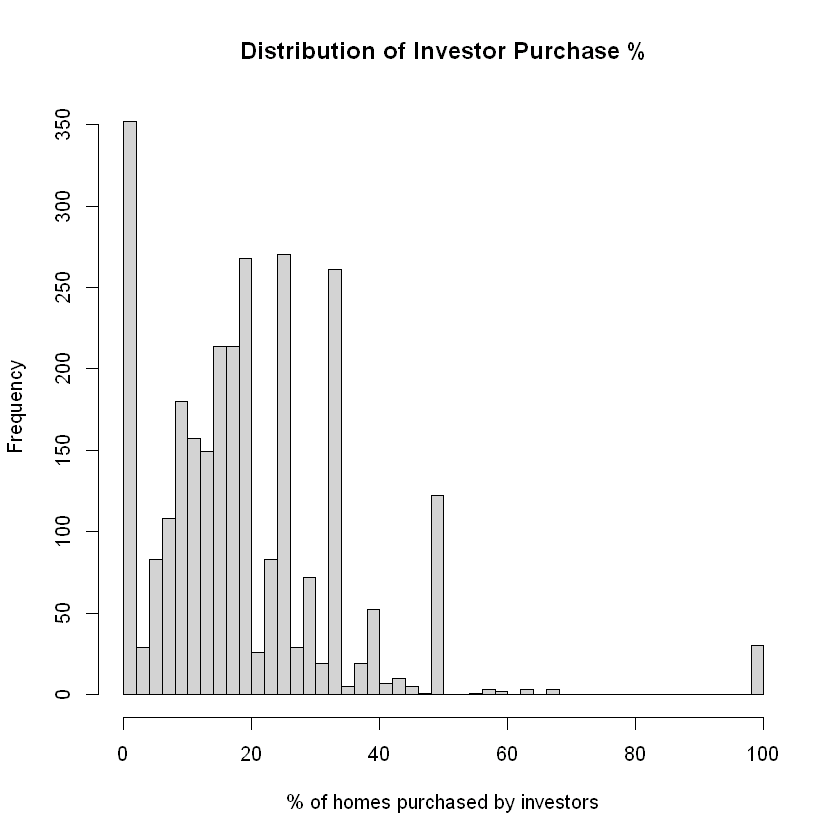

In [41]:
# Check for missing values in both datasets
cat("Missing values in market estimates:   ", sum(is.na(rfin_market)), "\n")
cat("Missing values in investor purchases: ", sum(is.na(rfin_purchases)), "\n")

# Summary statistics for the key variable: pct_invst
cat("\nSummary of pct_invst (% homes purchased by investors):\n")
summary(rfin_purchases$pct_invst)
hist(rfin_purchases$pct_invst, breaks = 50,
     main = "Distribution of Investor Purchase %",
     xlab = "% of homes purchased by investors")

In [42]:
# Check the tract key format in both Redfin files and the GeoPackage layer
cat("Redfin purchases tract type: ", class(rfin_purchases$tract), "\n")
cat("GeoPackage GEOID_TRACT type:  ", class(trct_1$GEOID_TRACT), "\n")

# Preview both keys to confirm format match
head(rfin_purchases$tract)
head(trct_1$GEOID_TRACT)

Redfin purchases tract type:  numeric 
GeoPackage GEOID_TRACT type:   character 


[1] 3.4003e+10 3.4003e+10 3.4003e+10 3.4003e+10 3.4003e+10 3.4003e+10

[1] "36081003400" "36081003900" "36081003600" "36081003700" "36081003800"
[6] "36081004001"

## 3.5 Joining Redfin Data to the Census Tract Layer

Joining the Redfin investor purchase data to the census tract spatial layer using the tract GEOID as the common key is needed.
A left join on the spatial layer ensures all 2,164 tracts are retained, those without Redfin data will have `NA` values.

In [44]:
# Convert tract to character to match GEOID_TRACT type
rfin_purchases$tract <- as.character(rfin_purchases$tract)
rfin_market$tract    <- as.character(rfin_market$tract)

# Join investor purchase data to spatial layer
trct_redfin <- trct_1 %>%
  left_join(rfin_purchases, by = c("GEOID_TRACT" = "tract"))

# Check join result
cat("Rows after join:", nrow(trct_redfin), "\n")
cat("Tracts with Redfin data:", sum(!is.na(trct_redfin$pct_invst)), "\n")
cat("Tracts without Redfin data:", sum(is.na(trct_redfin$pct_invst)), "\n")

Rows after join: 2164 
Tracts with Redfin data: 2062 
Tracts without Redfin data: 102 


In [45]:
# Also join market estimates
trct_redfin <- trct_redfin %>%
  left_join(rfin_market, by = c("GEOID_TRACT" = "tract"))

# Quick check on the joined dataset
names(trct_redfin)
summary(trct_redfin$pct_invst)

[1] "OBJECTID"       "STATEFP"        "COUNTYFP"       "TRACTCE"       
 [5] "GEOID"          "NAME"           "NAMELSAD"       "MTFCC"         
 [9] "FUNCSTAT"       "ALAND"          "AWATER"         "INTPTLAT"      
[13] "INTPTLON"       "GEOID_TRACT"    "CNT_BLK_GRP"    "GEO_ID"        
[17] "LABLE"          "STATE_FIPS"     "COUNTY_FIPS"    "TRACT_FIPS"    
[21] "DP05_0033E"     "DP05_0037E"     "DP05_0038E"     "DP05_0039E"    
[25] "DP05_0044E"     "DP05_0052E"     "DP05_0057E"     "DP05_0058E"    
[29] "DP05_0072E"     "DP05_0073E"     "DP05_0074E"     "DP05_0075E"    
[33] "DP05_0076E"     "DP05_0077E"     "DP05_0078E"     "DP05_0079E"    
[37] "DP05_0080E"     "DP05_0081E"     "DP05_0082E"     "DP05_0083E"    
[41] "DP05_0084E"     "DP05_0085E"     "DP05_5758E"     "DP05_0037P"    
[45] "DP05_0038P"     "DP05_0044P"     "DP05_3958P"     "OTHER_RACES"   
[49] "wht_prct"       "blck_prct"      "asi_prct"       "oth_prct"      
[53] "mex_prct"       "pr_prct"        "cub_prct"       "oth_hl_prct"   
[57] "blck_wht_rto"   "asi_wht_rto"    "oth_wht_rto"    "mex_pr_rto"    
[61] "cub_pr_rto"     "oth_hl_pr_rto"  "wht_dns"        "blck_dns"      
[65] "asi_dns"        "oth_dns"        "total_pop"      "DP05_0037E_LQ" 
[69] "DP05_0038E_LQ"  "DP05_0044E_LQ"  "OTHER_RACES_LQ" "est_invst"     
[73] "pct_invst"      "est_all_sales"  "rto_sales"      "X"             
[77] "est_msp"        "est_mlp"        "est_mhs"        "est_mnl"       
[81] "est_miv"        "geom"

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.    NA's 
   0.00   11.80   20.00   21.58   30.80  100.00     102 

## 3.6 Quick Visual Check

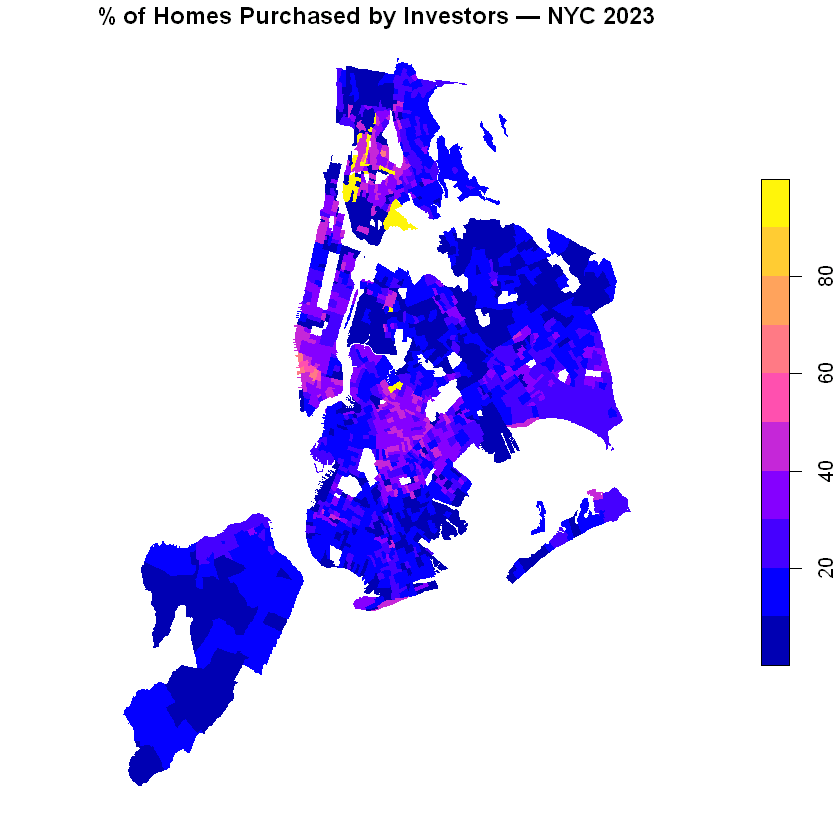

In [46]:
# Plot investor purchase percentage to verify spatial join
plot(
  trct_redfin["pct_invst"],
  main   = "% of Homes Purchased by Investors — NYC 2023",
  border = NA
)

## 3.7 Write Final Layer to GeoPackage

In [47]:
# Save the final joined layer for use in QGIS
st_write(trct_redfin, dsn = nyc_gpkg, layer = "trct_redfin_joined", delete_layer = TRUE)

cat("Layer 'trct_redfin_joined' written to", nyc_gpkg, "\n")

Deleting layer `trct_redfin_joined' failed
Writing layer `trct_redfin_joined' to data source 
  `cb_2022_us_tract510_500k_nyc.gpkg' using driver `GPKG'
Writing 2164 features with 81 fields and geometry type Multi Polygon.
Layer 'trct_redfin_joined' written to cb_2022_us_tract510_500k_nyc.gpkg 


---
## Session Info

The `sessionInfo()` function provides information related to the session and environment that can help for reproducibility purposes.

In [48]:
sessionInfo()

R version 4.5.1 (2025-06-13 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_United States.utf8 
[2] LC_CTYPE=English_United States.utf8   
[3] LC_MONETARY=English_United States.utf8
[4] LC_NUMERIC=C                          
[5] LC_TIME=English_United States.utf8    

time zone: America/Mexico_City
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] knitr_1.51     rmarkdown_2.31 dplyr_1.2.0    sp_2.2-1       sf_1.1-0      

loaded via a namespace (and not attached):
 [1] crayon_1.5.3       vctrs_0.7.2        cli_3.6.5          xfun_0.57         
 [5] rlang_1.1.7        DBI_1.3.0          KernSmooth_2.23-26 generics_0.1.4    
 [9] jsonlite_2.0.0     glue_1.8.0         htmltools_0.5.8.1  e1071_1.7-17      
[13] IRdisplay_1.1      IRkernel_1.3.2     grid_4.5.1         tibble

---
## References

- U.S. Census Bureau. American Community Survey (ACS), 2022. New York City.
- Redfin. 2023 NYC Investor Market & Purchase Estimates.
- Class material were used to create and describe specific code lines.